# This notebook was used in the mlcast meeting

# Code

In [20]:
from pathlib import Path
import os
import sys
import yaml
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import xarray as xr
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

%matplotlib inline

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

REGION = "belgium"
TIN = 4
TOUT = 20
CROP = 256
N_RANDOM_SAMPLES = 3
SEED = 60

# Standardized visualization setup
EVAL_EVENT_TS = [168615, 380070, 704352]
MAIN_EVENT_T = 168615
TARGET_SIZE = 704
FRAMES_TO_PLOT = (0, 4, 9, 14, 19)   # +5, +25, +50, +75, +100 min
RANDOM_MEMBER_SEED = 42
N_RANDOM_MEMBERS = 4

EVENT_LABELS = {
    168615: "2018-08-09 11:15",
    380070: "2020-08-12 16:30",
    704352: "2023-09-12 16:00",
}

def event_key(t_start):
    return f"t{int(t_start)}"

def event_title(t_start):
    return f"{event_key(t_start)} | {EVENT_LABELS.get(int(t_start), 'unknown time')}"

COMMON_FIGSIZE_LOSS = (8, 5)
COMMON_FIGSIZE_CONTEXT = (14, 3.5)
COMMON_FIGSIZE_FORECAST_PER_COL = 3.5


MLCAST_DIR = Path("/data/brussel/114/vsc11442/code/mlcast-ldcast")
SCRATCH_DIR = Path(os.environ.get("VSC_SCRATCH", "/scratch/brussel/114/vsc11442"))

# Where old/large runs are archived after moving them out of $VSC_DATA.
ARCHIVE_DIR = SCRATCH_DIR / "mlcast_runs_archive"
CONVGRU_RESULTS_DIR = ARCHIVE_DIR / "convgru"
LDCAST_RESULTS_DIR = ARCHIVE_DIR / "ldcast"

os.chdir(MLCAST_DIR)
if str(MLCAST_DIR) not in sys.path:
    sys.path.insert(0, str(MLCAST_DIR))
if str(MLCAST_DIR / "src") not in sys.path:
    sys.path.insert(0, str(MLCAST_DIR / "src"))

from mlcast.modules import ConvGRU
from radar_dataset_sampled import RadarDatasetNew
ENS_DIR = Path("/data/brussel/114/vsc11442/code/convgru-ensemble")

FULL_CONFIG = str(MLCAST_DIR / "src" / "new_config_data_sampled.yaml")

# Deterministic ConvGRU runs
METRIC_DIR_10pct_det = MLCAST_DIR / "results/convgru/convgru_10pct_b32_crop256/lightning_logs"
METRIC_DIR_full_det = MLCAST_DIR / "results/convgru/convgru_full_b32_crop256/lightning_logs"

# ConvGRU ensemble runs stay in the separate convgru-ensemble repo.
ENS_LOG_ROOT = ENS_DIR / "logs" / "CRPS_4past-20fut_noise"

# Initial ensemble runs.
RUN_10pct_ens = ENS_LOG_ROOT / "job12369419_4past-20fut_noise_bs32_lr1e-05"
RUN_full_ens = ENS_LOG_ROOT / "job12369418_4past-20fut_noise_bs32_lr1e-05"

# Resumed ensemble runs.
RUN_10pct_ens_resume = ENS_LOG_ROOT / "job12671975_4past-20fut_noise_bs32_lr1e-05_resume_to50_from_job12369419"
RUN_full_ens_resume = ENS_LOG_ROOT / "job12671974_4past-20fut_noise_bs32_lr1e-05_resume_to5_from_job12369418"

CKPTS = {
    "det_10pct": str(MLCAST_DIR / "results/convgru/convgru_10pct_b32_crop256/best-epoch21-step750244.ckpt"),
    "det_full": str(MLCAST_DIR / "results/convgru/convgru_full_b32_crop256/best-epoch02-step1021218.ckpt"),
    # Use the best validation checkpoints from the resumed ensemble runs.
    "ens_10pct": str(RUN_10pct_ens_resume / "checkpoints" / "best-val-4past-20fut_noise_bs32_lr1e-05_epepoch=049_lossval_loss=0.0714.ckpt"),
    "ens_full":  str(RUN_full_ens_resume  / "checkpoints" / "best-val-4past-20fut_noise_bs32_lr1e-05_epepoch=003_lossval_loss=0.0722.ckpt"),
}

print("Using scratch:", SCRATCH_DIR)
print("ConvGRU 10% metrics:", METRIC_DIR_10pct_det)
print("ConvGRU full metrics:", METRIC_DIR_full_det)
print("ConvGRU ensemble 10% initial:", RUN_10pct_ens)
print("ConvGRU ensemble 10% resumed:", RUN_10pct_ens_resume)
print("ConvGRU ensemble full initial:", RUN_full_ens)
print("ConvGRU ensemble full resumed:", RUN_full_ens_resume)


Using scratch: /scratch/brussel/114/vsc11442
ConvGRU 10% metrics: /data/brussel/114/vsc11442/code/mlcast-ldcast/results/convgru/convgru_10pct_b32_crop256/lightning_logs
ConvGRU full metrics: /data/brussel/114/vsc11442/code/mlcast-ldcast/results/convgru/convgru_full_b32_crop256/lightning_logs
ConvGRU ensemble 10% initial: /data/brussel/114/vsc11442/code/convgru-ensemble/logs/CRPS_4past-20fut_noise/job12369419_4past-20fut_noise_bs32_lr1e-05
ConvGRU ensemble 10% resumed: /data/brussel/114/vsc11442/code/convgru-ensemble/logs/CRPS_4past-20fut_noise/job12671975_4past-20fut_noise_bs32_lr1e-05_resume_to50_from_job12369419
ConvGRU ensemble full initial: /data/brussel/114/vsc11442/code/convgru-ensemble/logs/CRPS_4past-20fut_noise/job12369418_4past-20fut_noise_bs32_lr1e-05
ConvGRU ensemble full resumed: /data/brussel/114/vsc11442/code/convgru-ensemble/logs/CRPS_4past-20fut_noise/job12671974_4past-20fut_noise_bs32_lr1e-05_resume_to5_from_job12369418


In [21]:
def load_tb(run_dir, prefer_train_val=True):
    run_dir = Path(run_dir)
    event_files = sorted(run_dir.glob("events.out.tfevents.*"))

    if not event_files:
        raise FileNotFoundError(f"No TensorBoard event files found in {run_dir}")

    if prefer_train_val:
        for f in event_files:
            ea = EventAccumulator(str(f))
            ea.Reload()
            tags = ea.Tags().get("scalars", [])
            has_train_val = any(
                ("train" in t.lower() or "val" in t.lower())
                for t in tags
            )
            if has_train_val:
                print(f"Loaded train/val event file: {f.name}")
                print("Tags:", tags)
                return ea

    # fallback: load newest event file
    f = event_files[-1]
    ea = EventAccumulator(str(f))
    ea.Reload()
    print(f"Loaded fallback event file: {f.name}")
    print("Tags:", ea.Tags().get("scalars", []))
    return ea

def tb_to_df(ea, tag, value_col):
    events = ea.Scalars(tag)
    return pd.DataFrame({
        "epoch": range(len(events)),
        "step": [e.step for e in events],
        "wall_time": [e.wall_time for e in events],
        value_col: [e.value for e in events],
    })

In [22]:
# Deterministic runs
v_10pct_det0 = pd.read_csv(os.path.join(METRIC_DIR_10pct_det, "version_0", "metrics.csv"))
v_full_det0 = pd.read_csv(os.path.join(METRIC_DIR_full_det, "version_0", "metrics.csv"))

# Ensemble runs: initial run + resumed run.
ea_10pct_ens0 = load_tb(RUN_10pct_ens, prefer_train_val=True)
ea_10pct_ens1 = load_tb(RUN_10pct_ens_resume, prefer_train_val=True)
ea_full_ens0 = load_tb(RUN_full_ens, prefer_train_val=True)
ea_full_ens1 = load_tb(RUN_full_ens_resume, prefer_train_val=True)


Loaded train/val event file: events.out.tfevents.1780827506.node802.hydra.os.638501.0
Tags: ['hp_metric', 'lr-Adam', 'train_loss_step', 'train_ensemble_std_step', 'epoch', 'val_loss', 'val_ensemble_std', 'train_loss_epoch', 'train_ensemble_std_epoch']
Loaded train/val event file: events.out.tfevents.1782346178.node800.hydra.os.3081301.0
Tags: ['hp_metric', 'lr-Adam', 'train_loss_step', 'train_ensemble_std_step', 'epoch', 'val_loss', 'val_ensemble_std', 'train_loss_epoch', 'train_ensemble_std_epoch']
Loaded train/val event file: events.out.tfevents.1780827475.node801.hydra.os.855166.0
Tags: ['hp_metric', 'lr-Adam', 'train_loss_step', 'train_ensemble_std_step', 'epoch', 'val_loss', 'val_ensemble_std', 'train_loss_epoch', 'train_ensemble_std_epoch']
Loaded train/val event file: events.out.tfevents.1782342904.node800.hydra.os.3045389.0
Tags: ['hp_metric', 'lr-Adam', 'train_loss_step', 'train_ensemble_std_step', 'epoch', 'val_loss', 'val_ensemble_std', 'train_loss_epoch', 'train_ensemble_st

In [23]:
train_epoch = (
    pd.concat([v_10pct_det0[["epoch", "step", "train/loss_epoch"]]])
    .dropna()
    .sort_values("step")
    .drop_duplicates(subset=["epoch", "step"], keep="last")
)

val_epoch = (
    pd.concat([v_10pct_det0[["epoch", "step", "val/loss_epoch"]]])
    .dropna()
    .sort_values("step")
    .drop_duplicates(subset=["epoch", "step"], keep="last")
)

train_full_det = (
    pd.concat([v_full_det0[["epoch", "step", "train/loss_epoch"]]])
    .dropna()
    .sort_values("step")
    .drop_duplicates(subset=["epoch", "step"], keep="last")
)

val_full_det = (
    pd.concat([v_full_det0[["epoch", "step", "val/loss_epoch"]]])
    .dropna()
    .sort_values("step")
    .drop_duplicates(subset=["epoch", "step"], keep="last")
)

# because the resume renumbered the epochs
def resume_ens(df0, df1, overlap=0, sort_cols=("wall_time", "step")):
    cols0 = [c for c in sort_cols if c in df0.columns]
    cols1 = [c for c in sort_cols if c in df1.columns]

    a = df0.sort_values(cols0).reset_index(drop=True).copy() if cols0 else df0.reset_index(drop=True).copy()
    b = df1.sort_values(cols1).reset_index(drop=True).copy() if cols1 else df1.reset_index(drop=True).copy()

    # Rebuild a clean continuous epoch axis
    a["epoch"] = np.arange(len(a))
    b["epoch"] = np.arange(len(a) - overlap, len(a) - overlap + len(b))

    out = pd.concat([a, b], ignore_index=True)

    # If the resumed run repeated the last epoch once, keep the resumed value
    out = out.drop_duplicates(subset=["epoch"], keep="last")

    return out.sort_values("epoch").reset_index(drop=True)

train_epoch_10pct_ens = resume_ens(
    tb_to_df(ea_10pct_ens0, "train_loss_epoch", "train/loss_epoch"),
    tb_to_df(ea_10pct_ens1, "train_loss_epoch", "train/loss_epoch"),
)
val_epoch_10pct_ens = resume_ens(
    tb_to_df(ea_10pct_ens0, "val_loss", "val/loss_epoch"),
    tb_to_df(ea_10pct_ens1, "val_loss", "val/loss_epoch"),
)

train_full_ens = resume_ens(
    tb_to_df(ea_full_ens0, "train_loss_epoch", "train/loss_epoch"),
    tb_to_df(ea_full_ens1, "train_loss_epoch", "train/loss_epoch"),
)
val_full_ens = resume_ens(
    tb_to_df(ea_full_ens0, "val_loss", "val/loss_epoch"),
    tb_to_df(ea_full_ens1, "val_loss", "val/loss_epoch"),
)

# Free TensorBoard EventAccumulator objects after converting them to pandas DataFrames.
# This keeps the resumed ConvGRU ensemble loss curves, but avoids carrying the raw event logs
# into the LDCast NPZ plotting section.
import gc
for _name in ["ea_10pct_ens0", "ea_10pct_ens1", "ea_full_ens0", "ea_full_ens1"]:
    globals().pop(_name, None)
gc.collect()


0

In [24]:
# =========================
# Shared helpers: data, model loading, rain-rate conversion, and plotting
# =========================

import matplotlib.colors as mcolors


# -------------------------
# YAML / validation dataset
# -------------------------

def load_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)


def build_val_dataset(config_path):
    """
    Build validation dataset using the same normalized-dBZ transform as training.
    """
    data_sources = load_yaml(config_path)
    data_sources[REGION]["radar"]["transform_precip_to_dbz"] = True

    ds = RadarDatasetNew(
        mode="val",
        regions=[REGION],
        is_primary_source=True,
        inputs=["radar_past"],
        targets=["radar_future"],
        data_sources=data_sources,
        number_of_past_radar_time_steps=TIN,
        number_of_future_radar_time_steps=TOUT,
        crop_size=CROP,
        allowed_nan_fraction=1.0,
    )
    return ds


# -------------------------
# Deterministic ConvGRU loading
# -------------------------

def extract_net_state_dict(ckpt):
    """
    Extract raw ConvGRU EncoderDecoder weights from different checkpoint formats.

    Handles keys such as:
      - encoder.blocks...
      - net.encoder.blocks...
      - net.net.encoder.blocks...
      - model.encoder.blocks...
      - module.encoder.blocks...
    """
    if isinstance(ckpt, dict) and "state_dict" in ckpt:
        state = ckpt["state_dict"]
    else:
        state = ckpt

    cleaned = {}

    for k, v in state.items():
        new_k = k

        for prefix in ["net.net.", "net.", "model.net.", "model.", "module."]:
            if new_k.startswith(prefix):
                new_k = new_k[len(prefix):]
                break

        cleaned[new_k] = v

    return cleaned


def load_model(ckpt_path, model_type, device="cpu"):
    """
    Load deterministic ConvGRU checkpoint.
    """
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

    if model_type == "det":
        net = ConvGRU()
    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    net.load_state_dict(extract_net_state_dict(ckpt), strict=True)
    net.to(device)
    net.eval()

    return net, ckpt


def sample_to_model_input(sample):
    """
    Convert one RadarDatasetNew sample to model input format.

    sample["radar_past"]:   [C, T, H, W] -> x: [1, T, C, H, W]
    sample["radar_future"]: [C, T, H, W] -> y: [1, T, C, H, W]
    """
    x = sample["radar_past"].unsqueeze(0).permute(0, 2, 1, 3, 4).contiguous()
    y = sample["radar_future"].unsqueeze(0).permute(0, 2, 1, 3, 4).contiguous()
    return x, y


@torch.no_grad()
def predict_model(model, x, tout=TOUT):
    """
    Deterministic ConvGRU prediction.
    """
    return model(x, tout)


# =========================
# Normalized dBZ / rain-rate conversion helpers
# =========================

DBZ_MEAN = 30.0
DBZ_STD = 30.0
ZR_A = 200.0
ZR_B = 1.6
DBZ_MIN = 0.0
DBZ_MAX = 60.0


def as_numpy(x):
    """
    Convert torch Tensor or NumPy-like input to NumPy array.
    Keeps NaNs.
    """
    if isinstance(x, torch.Tensor):
        return x.detach().float().cpu().numpy()
    return np.asarray(x, dtype=np.float32)


def norm_to_dbz_np(x_norm):
    """
    Convert normalized dBZ to dBZ.

    Training normalization:
        x_norm = (dBZ - 30) / 30

    Therefore:
        dBZ = x_norm * 30 + 30
    """
    x_norm = as_numpy(x_norm)
    return x_norm * DBZ_STD + DBZ_MEAN


def dbz_to_rainrate_np(dbz):
    """
    Convert dBZ to rain rate in mm/hr using Z = a R^b.

    dBZ = 10 log10(Z)
    Z = 10 ** (dBZ / 10)
    R = (Z / a) ** (1 / b)
    """
    dbz = as_numpy(dbz)

    # Keep NaNs as NaNs.
    rr = np.full_like(dbz, np.nan, dtype=np.float32)

    valid = np.isfinite(dbz)
    dbz_valid = np.clip(dbz[valid], DBZ_MIN, DBZ_MAX)

    z = 10.0 ** (dbz_valid / 10.0)
    rr[valid] = (z / ZR_A) ** (1.0 / ZR_B)

    return rr


def to_rainrate_np(x_norm):
    """
    Main function to use in the notebook.

    Input:
        normalized dBZ, either torch.Tensor or np.ndarray

    Output:
        rain rate in mm/hr, np.ndarray
    """
    return dbz_to_rainrate_np(norm_to_dbz_np(x_norm))

# -------------------------
# Institute precipitation colormap
# -------------------------

def _get_precip_cmap_norm():
    color_list = [
        "white", "cyan", "deepskyblue", "dodgerblue", "blue",
        "chartreuse", "limegreen", "green", "darkgreen",
        "yellow", "gold", "orange", "red", "magenta", "darkmagenta",
    ]

    clevs = [
        0.0, 0.1, 0.25, 0.4, 0.63, 1, 1.6, 2.5,
        4, 6.3, 10, 16, 25, 40, 63, 100,
    ]

    units = "eq. mm/hr"

    cmap_precip = mcolors.ListedColormap(color_list)
    cmap_precip.set_bad(color=(1, 1, 1, 0))

    norm_precip = mcolors.BoundaryNorm(clevs, cmap_precip.N, clip=True)

    return cmap_precip, norm_precip, units, clevs


PRECIP_CMAP, PRECIP_NORM, PRECIP_UNITS, PRECIP_LEVELS = _get_precip_cmap_norm()


def imshow_precip(ax, arr, title=None):
    """
    Plot a rain-rate field using the institute precipitation palette.

    arr must already be in rain-rate units.
    """
    arr = np.asarray(arr, dtype=np.float32)

    im = ax.imshow(
        arr,
        origin="upper",
        cmap=PRECIP_CMAP,
        norm=PRECIP_NORM,
    )

    if title is not None:
        ax.set_title(title, fontsize=10)

    ax.set_xticks([])
    ax.set_yticks([])

    return im

# =========================
# Full-domain event loading helpers used by ConvGRU, U-Net and PySTEPS
# =========================

def rainrate_to_norm_dbz_np(rr, a=ZR_A, b=ZR_B):
    """Convert rain rate in mm/hr to normalized dBZ used by the neural models."""
    rr = np.asarray(rr, dtype=np.float32)
    norm = np.full_like(rr, np.nan, dtype=np.float32)

    valid = np.isfinite(rr)
    positive = valid & (rr > 0)

    dbz = np.zeros_like(rr, dtype=np.float32)
    dbz[positive] = 10.0 * np.log10(a * np.power(rr[positive], b))
    dbz = np.clip(dbz, DBZ_MIN, DBZ_MAX)

    norm[valid] = (dbz[valid] - DBZ_MEAN) / DBZ_STD
    return norm.astype(np.float32)


def pad_last_two_dims_to_square(arr, target_size=TARGET_SIZE, fill_value=np.nan):
    """Symmetrically pad the last two dimensions to target_size × target_size."""
    arr = np.asarray(arr)
    h, w = arr.shape[-2], arr.shape[-1]

    if h > target_size or w > target_size:
        raise ValueError(f"Input domain {h}x{w} is larger than target {target_size}x{target_size}")

    pad_h = target_size - h
    pad_w = target_size - w
    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left

    pad_spec = [(0, 0)] * arr.ndim
    pad_spec[-2] = (pad_top, pad_bottom)
    pad_spec[-1] = (pad_left, pad_right)

    padded = np.pad(arr, pad_spec, mode="constant", constant_values=fill_value)
    pad_info = {
        "original_h": h,
        "original_w": w,
        "pad_top": pad_top,
        "pad_bottom": pad_bottom,
        "pad_left": pad_left,
        "pad_right": pad_right,
        "target_size": target_size,
    }
    return padded, pad_info


def _radar_cfg_from_yaml_or_script(config_path, region=REGION):
    """Read radar zarr path and variable name from an MLCast config."""
    scripts_dir = MLCAST_DIR / "scripts"
    if str(scripts_dir) not in sys.path:
        sys.path.insert(0, str(scripts_dir))

    try:
        from Minh_read_mlcast_yaml import load_radar_cfg as _load_radar_cfg
        cfg = _load_radar_cfg(str(config_path), region)
        return cfg["zarr_path"], cfg["var_name"]
    except Exception:
        raw = load_yaml(config_path)
        radar = raw[region]["radar"]
        zarr_path = (
            radar.get("zarr_path")
            or radar.get("path")
            or radar.get("data_path")
            or radar.get("filename")
        )
        var_name = (
            radar.get("var_name")
            or radar.get("variable_name")
            or radar.get("standard_name")
            or "precip_intensity_EDK"
        )
        if zarr_path is None:
            raise KeyError(f"Could not find zarr path in {config_path}")
        return zarr_path, var_name


def load_full_domain_sequence_from_config(
    config_path=FULL_CONFIG,
    t_start=MAIN_EVENT_T,
    total_frames=TIN + TOUT,
    target_size=TARGET_SIZE,
):
    """
    Load one full-domain RADCLIM sequence and return normalized-dBZ arrays.

    Returns
    -------
    orig_norm_masked : [T, target_size, target_size]
        Normalized dBZ with NaNs preserved outside valid radar data.
    model_input : [T, target_size, target_size]
        Same field but NaNs filled with normalized 0 dBZ / no-rain value (-1).
    valid_mask : [T, target_size, target_size]
        True where raw RADCLIM data are finite.
    pad_info : dict
        Padding metadata.
    """
    import xarray as xr

    zarr_path, var_name = _radar_cfg_from_yaml_or_script(config_path, REGION)

    ds = xr.open_zarr(zarr_path)
    rr = ds[var_name].isel(time=slice(int(t_start), int(t_start) + total_frames)).values.astype(np.float32)

    norm = rainrate_to_norm_dbz_np(rr)
    norm_padded, pad_info = pad_last_two_dims_to_square(norm, target_size=target_size, fill_value=np.nan)
    valid_mask = np.isfinite(norm_padded)

    # Normalized 0 dBZ value, only for model input.
    model_input = np.where(valid_mask, norm_padded, -1.0).astype(np.float32)

    print(f"Loaded full-domain event {event_title(t_start)}")
    print("Raw rain-rate shape:", rr.shape)
    print("Padded normalized shape:", norm_padded.shape)
    print("Valid fraction:", float(valid_mask.mean()))
    return norm_padded.astype(np.float32), model_input, valid_mask, pad_info


def make_case_dict(
    past_norm,
    truth_norm,
    samples_norm,
    t_start,
    model_name,
    mode="full_domain",
):
    """Create the common case format used by all plotting functions."""
    samples_norm = np.asarray(samples_norm, dtype=np.float32)

    pred_mean = np.nanmean(samples_norm, axis=0).astype(np.float32)
    pred_std = (
        np.nanstd(samples_norm, axis=0).astype(np.float32)
        if samples_norm.shape[0] > 1
        else np.zeros_like(pred_mean, dtype=np.float32)
    )

    return {
        "past": np.asarray(past_norm, dtype=np.float32),
        "truth": np.asarray(truth_norm, dtype=np.float32),
        "samples": samples_norm.astype(np.float32),
        "pred_mean": pred_mean,
        "pred_std": pred_std,
        "tin": np.array(TIN),
        "tout": np.array(TOUT),
        "n_members": np.array(samples_norm.shape[0]),
        "t_start": np.array(int(t_start)),
        "model_name": np.array(str(model_name)),
        "mode": np.array(str(mode)),
    }


In [25]:
# =========================
# Load validation events for ConvGRU
# =========================

full_domain_events = {}

for t_start in EVAL_EVENT_TS:
    orig_norm, model_input, valid_mask, pad_info = load_full_domain_sequence_from_config(
        config_path=FULL_CONFIG,
        t_start=t_start,
        total_frames=TIN + TOUT,
        target_size=TARGET_SIZE,
    )
    full_domain_events[event_key(t_start)] = {
        "t_start": int(t_start),
        "orig_norm": orig_norm,
        "model_input": model_input,
        "valid_mask": valid_mask,
        "pad_info": pad_info,
    }

print("Loaded standardized full-domain events:")
for k, ev in full_domain_events.items():
    print(k, "->", ev["orig_norm"].shape, "valid fraction", ev["valid_mask"].mean())


Loaded full-domain event t168615 | 2018-08-09 11:15
Raw rain-rate shape: (24, 700, 700)
Padded normalized shape: (24, 704, 704)
Valid fraction: 0.6115348542688963
Loaded full-domain event t380070 | 2020-08-12 16:30
Raw rain-rate shape: (24, 700, 700)
Padded normalized shape: (24, 704, 704)
Valid fraction: 0.6580933289751205
Loaded full-domain event t704352 | 2023-09-12 16:00
Raw rain-rate shape: (24, 700, 700)
Padded normalized shape: (24, 704, 704)
Valid fraction: 0.6565616492069128
Loaded standardized full-domain events:
t168615 -> (24, 704, 704) valid fraction 0.6115348542688963
t380070 -> (24, 704, 704) valid fraction 0.6580933289751205
t704352 -> (24, 704, 704) valid fraction 0.6565616492069128


In [26]:
ENS_DIR = Path("/data/brussel/114/vsc11442/code/convgru-ensemble")
ENS_DIR_STR = str(ENS_DIR.resolve())

print("ENS_DIR =", ENS_DIR_STR)
print("repo exists:", ENS_DIR.is_dir())
print("package exists:", (ENS_DIR / "convgru_ensemble").is_dir())

if ENS_DIR_STR not in sys.path:
    sys.path.insert(0, ENS_DIR_STR)

from convgru_ensemble.lightning_model import RadarLightningModel


def load_ensemble_model(ckpt_path, device="cpu"):
    """Load the FBK ConvGRU ensemble Lightning model from a checkpoint."""
    ckpt_path = Path(ckpt_path)
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Missing ensemble checkpoint: {ckpt_path}")

    model = RadarLightningModel.from_checkpoint(str(ckpt_path), device=device)
    model = model.to(device)
    model.eval()
    print("Loaded ensemble model:", ckpt_path)
    return model, {"backend": "fbk"}


def ensemble_output_to_members(pred, tout=TOUT):
    """
    Convert ensemble prediction output to members with shape (E, T, H, W).

    Known/possible layouts:
      - (B, T, E, H, W)
      - (B, E, T, H, W)
      - (E, T, H, W)
    """
    pred = pred.detach().cpu()

    if pred.ndim == 5:
        # Remove batch dimension for B=1.
        pred0 = pred[0]
        if pred0.shape[0] == tout:      # (T, E, H, W)
            return pred0.permute(1, 0, 2, 3).contiguous()
        if pred0.shape[1] == tout:      # (E, T, H, W)
            return pred0.contiguous()
        raise ValueError(f"Cannot infer ensemble layout from prediction shape {tuple(pred.shape)}")

    if pred.ndim == 4:
        if pred.shape[1] == tout:       # (E, T, H, W)
            return pred.contiguous()
        if pred.shape[0] == tout:       # (T, E, H, W)
            return pred.permute(1, 0, 2, 3).contiguous()
        raise ValueError(f"Cannot infer ensemble layout from prediction shape {tuple(pred.shape)}")

    raise ValueError(f"Unexpected ensemble prediction shape: {tuple(pred.shape)}")


models = {}

# Deterministic mlcast ConvGRU models.
models["det_10pct"], _ = load_model(CKPTS["det_10pct"], "det", device=DEVICE)
models["det_full"],  _ = load_model(CKPTS["det_full"],  "det", device=DEVICE)

# ConvGRU ensemble models.
models["ens_10pct"], _ = load_ensemble_model(CKPTS["ens_10pct"], device=DEVICE)
models["ens_full"],  _ = load_ensemble_model(CKPTS["ens_full"],  device=DEVICE)

print("Loaded models:", list(models.keys()))


ENS_DIR = /vscmnt/brussel_pixiu_data/_data_brussel/114/vsc11442/code/convgru-ensemble
repo exists: True
package exists: True
Using masked loss: CRPS with params {'temporal_lambda': 0.01} and reduction mean
Using ensemble mode: 4 independent ensemble members will be generated.
Loaded ensemble model: /data/brussel/114/vsc11442/code/convgru-ensemble/logs/CRPS_4past-20fut_noise/job12671975_4past-20fut_noise_bs32_lr1e-05_resume_to50_from_job12369419/checkpoints/best-val-4past-20fut_noise_bs32_lr1e-05_epepoch=049_lossval_loss=0.0714.ckpt
Using masked loss: CRPS with params {'temporal_lambda': 0.01} and reduction mean
Using ensemble mode: 4 independent ensemble members will be generated.
Loaded ensemble model: /data/brussel/114/vsc11442/code/convgru-ensemble/logs/CRPS_4past-20fut_noise/job12671974_4past-20fut_noise_bs32_lr1e-05_resume_to5_from_job12369418/checkpoints/best-val-4past-20fut_noise_bs32_lr1e-05_epepoch=003_lossval_loss=0.0722.ckpt
Loaded models: ['det_10pct', 'det_full', 'ens_10pc

/apps/brussel/RL9/broadwell/software/PyTorch-Lightning/2.5.2-foss-2024a-CUDA-12.6.0/lib/python3.12/site-packages/pytorch_lightning/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.6.0, which is newer than your current Lightning version: v2.5.2


In [27]:
# =========================
# Run ConvGRU predictions
# =========================

def convgru_prediction_to_samples(pred, deterministic=False):
    """Convert ConvGRU output to samples [M, T, H, W] in normalized dBZ space."""
    pred = pred.detach().float().cpu()

    if deterministic:
        # [B, T, C, H, W] -> [1, T, H, W]
        if pred.ndim != 5 or pred.shape[2] != 1:
            raise ValueError(f"Unexpected deterministic ConvGRU output shape: {tuple(pred.shape)}")
        return pred[0, :, 0].numpy()[None, ...]

    # ConvGRU ensemble: [B, T, E, H, W] or [B, E, T, H, W]
    members = ensemble_output_to_members(pred, tout=TOUT)
    return members.numpy()


@torch.no_grad()
def predict_convgru_full_domain_case(model, event_data, name, deterministic=False):
    """Run ConvGRU full-domain inference live and return a case dictionary."""
    t_start = int(event_data["t_start"])

    x_np = event_data["model_input"][:TIN]  # [Tin, H, W]
    x = torch.from_numpy(x_np[:, None]).unsqueeze(0).float().to(DEVICE)  # [1, Tin, 1, H, W]

    print("Running", name, "on", event_title(t_start), "x=", tuple(x.shape))
    y_hat = predict_model(model, x, TOUT)
    samples = convgru_prediction_to_samples(y_hat, deterministic=deterministic)

    case = make_case_dict(
        past_norm=event_data["orig_norm"][:TIN],
        truth_norm=event_data["orig_norm"][TIN:TIN + TOUT],
        samples_norm=samples,
        t_start=t_start,
        model_name=name,
    )

    del x, y_hat
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return case


convgru_cases_by_event = {}

for ev_key, ev in full_domain_events.items():
    convgru_cases_by_event[ev_key] = {}
    convgru_cases_by_event[ev_key]["ConvGRU 10%"] = predict_convgru_full_domain_case(
        models["det_10pct"], ev, "ConvGRU 10%", deterministic=True
    )
    convgru_cases_by_event[ev_key]["ConvGRU full"] = predict_convgru_full_domain_case(
        models["det_full"], ev, "ConvGRU full", deterministic=True
    )
    convgru_cases_by_event[ev_key]["ConvGRU ensemble 10%"] = predict_convgru_full_domain_case(
        models["ens_10pct"], ev, "ConvGRU ensemble 10%", deterministic=False
    )
    convgru_cases_by_event[ev_key]["ConvGRU ensemble full"] = predict_convgru_full_domain_case(
        models["ens_full"], ev, "ConvGRU ensemble full", deterministic=False
    )

print("ConvGRU full-domain cases:")
for ev_key, group in convgru_cases_by_event.items():
    print(ev_key, list(group.keys()))


Running ConvGRU 10% on t168615 | 2018-08-09 11:15 x= (1, 4, 1, 704, 704)
Running ConvGRU full on t168615 | 2018-08-09 11:15 x= (1, 4, 1, 704, 704)
Running ConvGRU ensemble 10% on t168615 | 2018-08-09 11:15 x= (1, 4, 1, 704, 704)
Running ConvGRU ensemble full on t168615 | 2018-08-09 11:15 x= (1, 4, 1, 704, 704)
Running ConvGRU 10% on t380070 | 2020-08-12 16:30 x= (1, 4, 1, 704, 704)
Running ConvGRU full on t380070 | 2020-08-12 16:30 x= (1, 4, 1, 704, 704)
Running ConvGRU ensemble 10% on t380070 | 2020-08-12 16:30 x= (1, 4, 1, 704, 704)
Running ConvGRU ensemble full on t380070 | 2020-08-12 16:30 x= (1, 4, 1, 704, 704)
Running ConvGRU 10% on t704352 | 2023-09-12 16:00 x= (1, 4, 1, 704, 704)
Running ConvGRU full on t704352 | 2023-09-12 16:00 x= (1, 4, 1, 704, 704)
Running ConvGRU ensemble 10% on t704352 | 2023-09-12 16:00 x= (1, 4, 1, 704, 704)
Running ConvGRU ensemble full on t704352 | 2023-09-12 16:00 x= (1, 4, 1, 704, 704)
ConvGRU full-domain cases:
t168615 ['ConvGRU 10%', 'ConvGRU full

In [28]:
# =========================
# Shared nowcasting visualization helpers
# =========================

def safe_nanmean_axis0(arr):
    """
    Like np.nanmean(arr, axis=0), but without RuntimeWarning
    when all values along axis=0 are NaN.
    """
    valid_count = np.sum(np.isfinite(arr), axis=0)
    valid_sum = np.nansum(arr, axis=0)

    out = np.full(arr.shape[1:], np.nan, dtype=np.float32)

    np.divide(
        valid_sum,
        valid_count,
        out=out,
        where=valid_count > 0,
    )

    return out

def case_to_rainrate_fields(case):
    """Convert a common case dictionary/NPZ to rain-rate fields."""
    past_rr = to_rainrate_np(case["past"])
    truth_rr = to_rainrate_np(case["truth"])
    samples_rr = to_rainrate_np(case["samples"])

    pred_mean_rr = safe_nanmean_axis0(samples_rr)
    pred_std_rr = (
        np.nanstd(samples_rr, axis=0)
        if samples_rr.shape[0] > 1
        else np.zeros_like(pred_mean_rr, dtype=np.float32)
    )
    abs_error_rr = np.abs(pred_mean_rr - truth_rr)

    return {
        "past_rr": past_rr,
        "truth_rr": truth_rr,
        "samples_rr": samples_rr,
        "pred_mean_rr": pred_mean_rr,
        "pred_std_rr": pred_std_rr,
        "abs_error_rr": abs_error_rr,
    }


def get_case_t_start(case):
    if "t_start" in case:
        try:
            return int(case["t_start"])
        except Exception:
            return int(np.asarray(case["t_start"]).item())
    return None


def plot_standard_context(case, title="Input context"):
    """Plot the same four input frames for any model case."""
    fields = case_to_rainrate_fields(case)
    past_rr = fields["past_rr"]

    fig, axes = plt.subplots(
        1,
        past_rr.shape[0],
        figsize=COMMON_FIGSIZE_CONTEXT,
        constrained_layout=True,
    )
    axes = np.asarray(axes).reshape(1, -1)[0]

    im = None
    for i, ax in enumerate(axes):
        rel_min = (i - (past_rr.shape[0] - 1)) * 5
        im = imshow_precip(ax, past_rr[i], title=f"Input {rel_min:+d} min")

    cbar = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.01)
    cbar.set_label(PRECIP_UNITS)
    fig.suptitle(title, fontsize=14)
    plt.show()


def plot_standard_forecast(
    case,
    title="Forecast",
    model_label="Prediction mean",
    frames=FRAMES_TO_PLOT,
    show_std="auto",
):
    """Plot truth, prediction mean, error, and optional ensemble spread in one consistent layout."""
    fields = case_to_rainrate_fields(case)
    truth_rr = fields["truth_rr"]
    pred_rr = fields["pred_mean_rr"]
    err_rr = fields["abs_error_rr"]
    std_rr = fields["pred_std_rr"]

    n_members = int(np.asarray(case["samples"]).shape[0])
    if show_std == "auto":
        show_std = n_members > 1

    frames = [int(f) for f in frames if 0 <= int(f) < truth_rr.shape[0]]

    rows = [
        ("Truth", truth_rr, PRECIP_UNITS),
        (model_label, pred_rr, PRECIP_UNITS),
        ("Absolute error", err_rr, f"Abs. error ({PRECIP_UNITS})"),
    ]
    if show_std:
        rows.append(("Ensemble std", std_rr, f"Std ({PRECIP_UNITS})"))

    fig, axes = plt.subplots(
        len(rows),
        len(frames),
        figsize=(COMMON_FIGSIZE_FORECAST_PER_COL * len(frames), 3.0 * len(rows)),
        constrained_layout=True,
    )
    axes = np.asarray(axes)
    if axes.ndim == 1:
        axes = axes.reshape(len(rows), -1)

    for r, (row_name, arr, cbar_label) in enumerate(rows):
        im = None
        for c, t in enumerate(frames):
            lead = (t + 1) * 5
            im = imshow_precip(axes[r, c], arr[t], title=f"{row_name}, +{lead} min")
        cbar = fig.colorbar(im, ax=axes[r, :], shrink=0.80, pad=0.01)
        cbar.set_label(cbar_label)

    fig.suptitle(title, fontsize=14)
    plt.show()


def plot_two_case_forecast_compare(
    case_a,
    case_b,
    label_a="10%",
    label_b="full",
    title="Forecast comparison",
    frames=FRAMES_TO_PLOT,
):
    """Compare two probabilistic/deterministic cases using the same event and lead times."""
    fields_a = case_to_rainrate_fields(case_a)
    fields_b = case_to_rainrate_fields(case_b)

    truth_rr = fields_a["truth_rr"]
    mean_a = fields_a["pred_mean_rr"]
    mean_b = fields_b["pred_mean_rr"]
    rows = [
        ("Truth", truth_rr, PRECIP_UNITS),
        (f"{label_a} mean", mean_a, PRECIP_UNITS),
        (f"{label_b} mean", mean_b, PRECIP_UNITS),
    ]

    frames = [int(f) for f in frames if 0 <= int(f) < truth_rr.shape[0]]

    fig, axes = plt.subplots(
        len(rows),
        len(frames),
        figsize=(COMMON_FIGSIZE_FORECAST_PER_COL * len(frames), 2.8 * len(rows)),
        constrained_layout=True,
    )
    axes = np.asarray(axes)
    if axes.ndim == 1:
        axes = axes.reshape(len(rows), -1)

    for r, (row_name, arr, cbar_label) in enumerate(rows):
        im = None
        for c, t in enumerate(frames):
            lead = (t + 1) * 5
            im = imshow_precip(axes[r, c], arr[t], title=f"{row_name}, +{lead} min")
        cbar = fig.colorbar(im, ax=axes[r, :], shrink=0.80, pad=0.01)
        cbar.set_label(cbar_label)

    fig.suptitle(title, fontsize=14)
    plt.show()


def plot_standard_members(
    case,
    title="Ensemble members",
    frames=FRAMES_TO_PLOT,
    members=None,
    n_random_members=N_RANDOM_MEMBERS,
    random_state=RANDOM_MEMBER_SEED,
):
    fields = case_to_rainrate_fields(case)
    samples_rr = fields["samples_rr"]
    n_members = samples_rr.shape[0]

    if n_members <= 1:
        print("Skipping member plot for deterministic case:", title)
        return

    if members is None:
        rng = np.random.default_rng(random_state)
        members = sorted(rng.choice(n_members, size=min(n_random_members, n_members), replace=False).tolist())
    else:
        members = [int(m) for m in members if 0 <= int(m) < n_members]

    frames = [int(f) for f in frames if 0 <= int(f) < samples_rr.shape[1]]

    fig, axes = plt.subplots(
        len(members),
        len(frames),
        figsize=(COMMON_FIGSIZE_FORECAST_PER_COL * len(frames), 2.8 * len(members)),
        constrained_layout=True,
    )
    axes = np.asarray(axes)
    if axes.ndim == 1:
        axes = axes.reshape(len(members), -1)

    im = None
    for r, m in enumerate(members):
        for c, t in enumerate(frames):
            lead = (t + 1) * 5
            im = imshow_precip(axes[r, c], samples_rr[m, t], title=f"Member {m + 1}, +{lead} min")

    cbar = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.01)
    cbar.set_label(PRECIP_UNITS)
    fig.suptitle(title, fontsize=14)
    plt.show()

# Backward-compatible aliases for LDcast/U-Net cells below.
_ldcast_to_rainrate_fields = case_to_rainrate_fields
plot_ldcast_context = plot_standard_context
plot_ldcast_members = plot_standard_members


In [29]:
# =========================
# Plot full-domain ConvGRU forecasts
# =========================
def plot_ConvGRU_deterministic():
    for ev_key, group in convgru_cases_by_event.items():
        t_start = int(group["ConvGRU 10%"]["t_start"])
        plot_standard_context(
            group["ConvGRU 10%"],
            title=f"ConvGRU input context | {event_title(t_start)}",
        )
    
        # Pairwise 10% vs full comparisons minimize repetition while keeping the style consistent.
        plot_two_case_forecast_compare(
            group["ConvGRU 10%"],
            group["ConvGRU full"],
            label_a="ConvGRU 10%",
            label_b="ConvGRU full",
            title=f"ConvGRU deterministic forecast comparison | {event_title(t_start)}",
            frames=FRAMES_TO_PLOT,
        )

def plot_ConvGRU_ensemble():
    for ev_key, group in convgru_cases_by_event.items():
        t_start = int(group["ConvGRU 10%"]["t_start"])
        plot_standard_context(
            group["ConvGRU 10%"],
            title=f"ConvGRU input context | {event_title(t_start)}",
        )
        plot_two_case_forecast_compare(
            group["ConvGRU ensemble 10%"],
            group["ConvGRU ensemble full"],
            label_a="ConvGRU ensemble 10%",
            label_b="ConvGRU ensemble full",
            title=f"ConvGRU ensemble forecast comparison | {event_title(t_start)}",
            frames=FRAMES_TO_PLOT,
        )

# =========================
# ConvGRU ensemble member plots for only 1 event
# =========================
def plot_ConvGRU_members(): 
    selected_event = event_key(MAIN_EVENT_T)
    if selected_event in convgru_cases_by_event:
        group = convgru_cases_by_event[selected_event]
        plot_standard_members(
            group["ConvGRU ensemble 10%"],
            title=f"ConvGRU ensemble 10% members | {event_title(MAIN_EVENT_T)}",
            frames=FRAMES_TO_PLOT,
            n_random_members=N_RANDOM_MEMBERS,
            random_state=RANDOM_MEMBER_SEED,
        )
        plot_standard_members(
            group["ConvGRU ensemble full"],
            title=f"ConvGRU ensemble full members | {event_title(MAIN_EVENT_T)}",
            frames=FRAMES_TO_PLOT,
            n_random_members=N_RANDOM_MEMBERS,
            random_state=RANDOM_MEMBER_SEED,
        )
    else:
        print("Main event not available for ConvGRU member plot:", selected_event)


In [30]:
# =========================
# Load LDCast NPZ cases
# =========================

LDCAST_VIS_DIR = Path("/data/brussel/114/vsc11442/code/mlcast-ldcast/results/ldcast_visuals")


def first_existing(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return None


def ldcast_case_path(split, epoch, t_start):
    """Prefer the new unmasked full-domain export if it exists; otherwise fall back to the older export."""
    split_name = "10pct" if split == "10%" else "full"
    return first_existing([
        LDCAST_VIS_DIR / f"ldcast_{split_name}_epoch{epoch}_TRUEFULL_UNMASKED_t{t_start}_m20_plms100.npz",
        LDCAST_VIS_DIR / f"ldcast_{split_name}_epoch{epoch}_t{t_start}_m20_plms100.npz",
    ])

LDCAST_CASE_PATHS = {}
for t_start in EVAL_EVENT_TS:
    p10 = ldcast_case_path("10%", "027", t_start)
    pfull = ldcast_case_path("full", "002", t_start)
    if p10 is not None:
        LDCAST_CASE_PATHS[f"LDCast 10% | {event_key(t_start)}"] = p10
    else:
        print("Missing LDCast 10% case:", event_key(t_start))
    if pfull is not None:
        LDCAST_CASE_PATHS[f"LDCast full | {event_key(t_start)}"] = pfull
    else:
        print("Missing LDCast full case:", event_key(t_start))

ldcast_cases = {
    name: np.load(path, allow_pickle=True)
    for name, path in LDCAST_CASE_PATHS.items()
}

print("Loaded LDCast cases:")
for name, case in ldcast_cases.items():
    print(
        f"{name:30s} | past={case['past'].shape} "
        f"truth={case['truth'].shape} samples={case['samples'].shape} | {LDCAST_CASE_PATHS[name].name}"
    )

ldcast_cases_by_event = {}
for name, case in ldcast_cases.items():
    t_label = name.split("|")[-1].strip()
    ldcast_cases_by_event.setdefault(t_label, {})
    if "10%" in name:
        ldcast_cases_by_event[t_label]["10%"] = case
    elif "full" in name:
        ldcast_cases_by_event[t_label]["full"] = case

print("Grouped LDCast cases:")
for t_label, group in ldcast_cases_by_event.items():
    print(t_label, "->", list(group.keys()))


Loaded LDCast cases:
LDCast 10% | t168615           | past=(4, 704, 704) truth=(20, 704, 704) samples=(20, 20, 704, 704) | ldcast_10pct_epoch027_t168615_m20_plms100.npz
LDCast full | t168615          | past=(4, 704, 704) truth=(20, 704, 704) samples=(20, 20, 704, 704) | ldcast_full_epoch002_t168615_m20_plms100.npz
LDCast 10% | t380070           | past=(4, 704, 704) truth=(20, 704, 704) samples=(20, 20, 704, 704) | ldcast_10pct_epoch027_t380070_m20_plms100.npz
LDCast full | t380070          | past=(4, 704, 704) truth=(20, 704, 704) samples=(20, 20, 704, 704) | ldcast_full_epoch002_t380070_m20_plms100.npz
LDCast 10% | t704352           | past=(4, 704, 704) truth=(20, 704, 704) samples=(20, 20, 704, 704) | ldcast_10pct_epoch027_t704352_m20_plms100.npz
LDCast full | t704352          | past=(4, 704, 704) truth=(20, 704, 704) samples=(20, 20, 704, 704) | ldcast_full_epoch002_t704352_m20_plms100.npz
Grouped LDCast cases:
t168615 -> ['10%', 'full']
t380070 -> ['10%', 'full']
t704352 -> ['10%',

In [31]:
# =========================
# LDCast visualization wrappers
# =========================

_ldcast_to_rainrate_fields = case_to_rainrate_fields
plot_ldcast_context = plot_standard_context
plot_ldcast_members = plot_standard_members


def plot_ldcast_context_compare(case_10, case_full, title=""):
    plot_two_case_forecast_compare(
        make_case_dict(
            past_norm=case_10["past"],
            truth_norm=case_10["past"],
            samples_norm=case_10["past"][None, :, :, :],
            t_start=get_case_t_start(case_10),
            model_name="LDCast 10% context",
            mode="context_only",
        ),
        make_case_dict(
            past_norm=case_full["past"],
            truth_norm=case_full["past"],
            samples_norm=case_full["past"][None, :, :, :],
            t_start=get_case_t_start(case_full),
            model_name="LDCast full context",
            mode="context_only",
        ),
        label_a="10% input",
        label_b="Full input",
        title=title,
        frames=tuple(range(min(TIN, case_10["past"].shape[0]))),
    )


def plot_ldcast_forecast_compare(case_10, case_full, title="", frames=FRAMES_TO_PLOT):
    plot_two_case_forecast_compare(
        case_10,
        case_full,
        label_a="LDCast 10%",
        label_b="LDCast full",
        title=title,
        frames=frames,
    )


In [32]:
# =========================
# Plot LDCast forecast comparison for all three exported events
# =========================
def plot_LDCast():
    for t_label, group in ldcast_cases_by_event.items():
        if "10%" in group:
            t_start = get_case_t_start(group["10%"])
            plot_standard_context(
                group["10%"],
                title=f"LDCast input context | {event_title(t_start)}",
            )
        if "10%" in group and "full" in group:
            t_start = get_case_t_start(group["10%"])
            plot_ldcast_forecast_compare(
                group["10%"],
                group["full"],
                title=f"LDCast forecast comparison | {event_title(t_start)}",
                frames=FRAMES_TO_PLOT,
            )

# =========================
# LDCast ensemble member plots for 1 event
# =========================
def plot_LDCast_members():
    selected_event = event_key(MAIN_EVENT_T)
    if selected_event in ldcast_cases_by_event:
        group = ldcast_cases_by_event[selected_event]
        plot_standard_members(
            group["10%"],
            title=f"LDCast 10% members | {event_title(MAIN_EVENT_T)}",
            frames=FRAMES_TO_PLOT,
            n_random_members=N_RANDOM_MEMBERS,
            random_state=RANDOM_MEMBER_SEED,
        )
        plot_standard_members(
            group["full"],
            title=f"LDCast full members | {event_title(MAIN_EVENT_T)}",
            frames=FRAMES_TO_PLOT,
            n_random_members=N_RANDOM_MEMBERS,
            random_state=RANDOM_MEMBER_SEED,
        )
    else:
        print("Main LDCast event is missing:", selected_event)



# Results
## Data

In [33]:
xr.open_zarr("/data/brussel/vo/000/bvo00029/data/observations/RADCLIMrates_2017_2023_5m_be_v1/RADCLIMrates_f16.zarr")

<xarray.Dataset> Size: 721GB
Dimensions:               (y: 700, x: 700, time: 736128)
Coordinates:
    lat                   (y, x) float64 4MB ...
    lon                   (y, x) float64 4MB ...
  * time                  (time) datetime64[ns] 6MB 2017-01-01 ... 2023-12-31...
  * x                     (x) float64 6kB 3.005e+05 3.015e+05 ... 9.995e+05
  * y                     (y) float64 6kB 9.995e+05 9.985e+05 ... 3.005e+05
Data variables:
    precip_intensity_EDK  (time, y, x) float16 721GB ...
Attributes:
    Comment:  The origin of the data is upper left and is correctly plotted a...

### Dataset split

Train: 2017 - 2020, 2022-11/2023

Validation: 5 consecutive days per month 2017 - 2020, 2022-11/2023

Test: 2021

**To avoid leakage between training and validation/test windows, a 2-hour buffer is removed around boundary between these datasets**

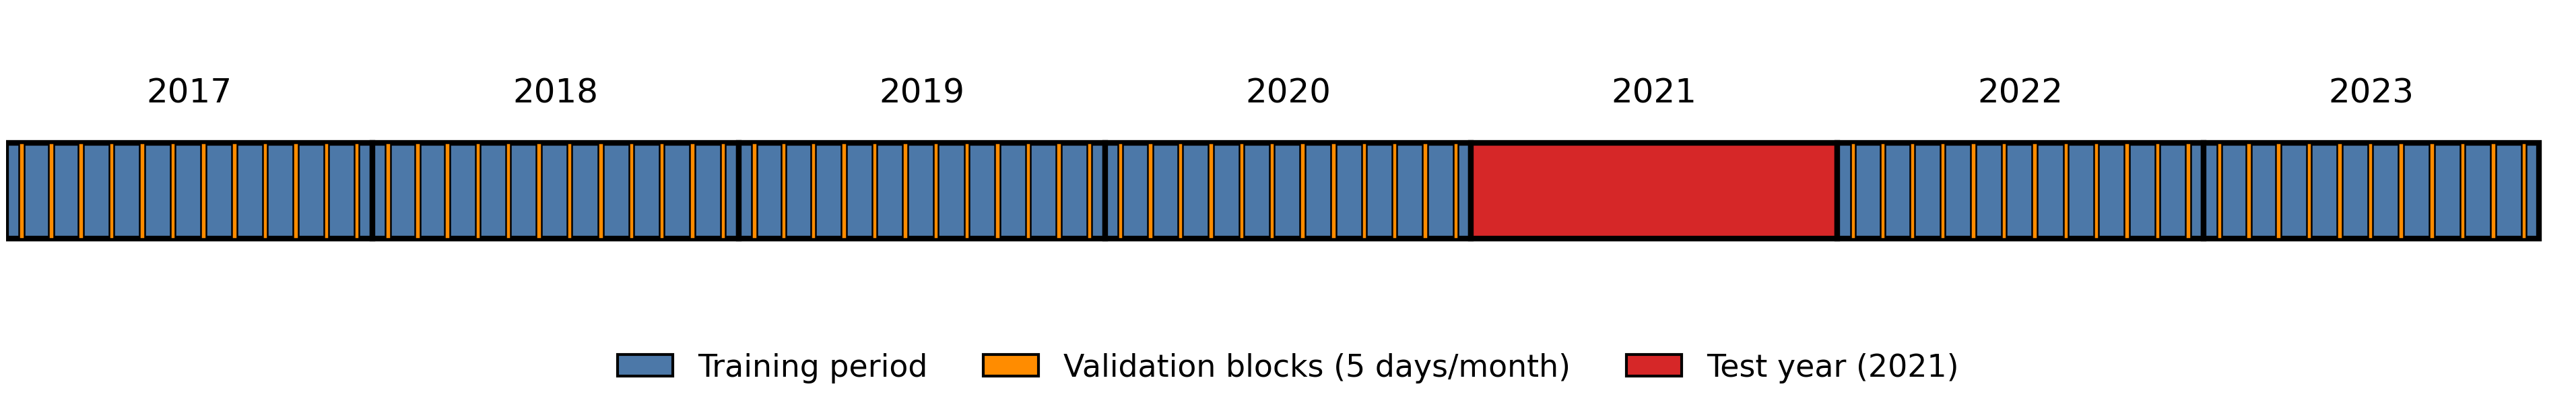

### Importance sampling

We ran importance sampling with the default configurations, this resulted in:

- Train:  10.892.994 sequences
- Val: 2.536.237 sequences

### Dataset size
Because the original dataset is large, we did 2 different runs for all models:
- Full: in each epoch, all the importance sampled sequences are seen
- 10%: in each epoch, only a fixed 10% of the importance sampled sequences are seen

## Models

3 different events are studied, first (ensemble) mean are plotted, then ensemble members

All plots have size 704x704

### ConvGRU:
Trained with crop size 256x256
- Deterministic: MSE
- Ensemble: 4 members, CRPS

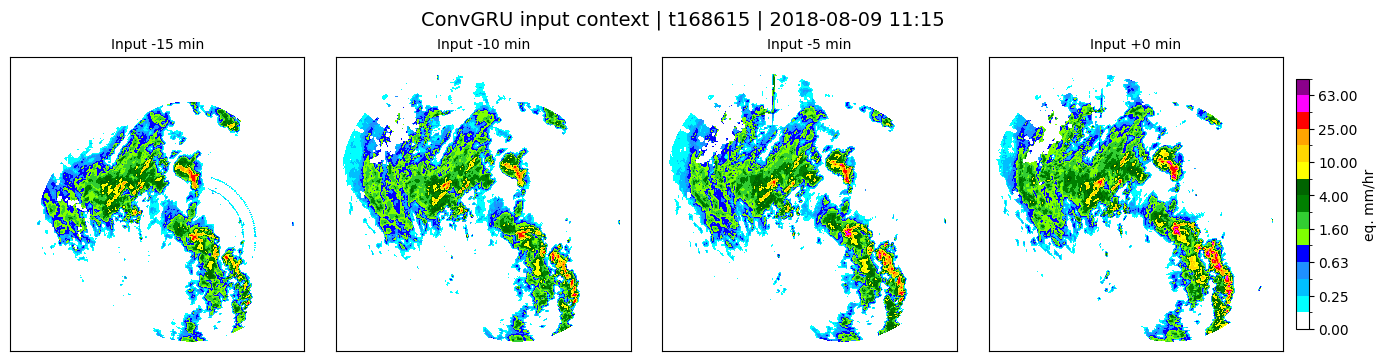

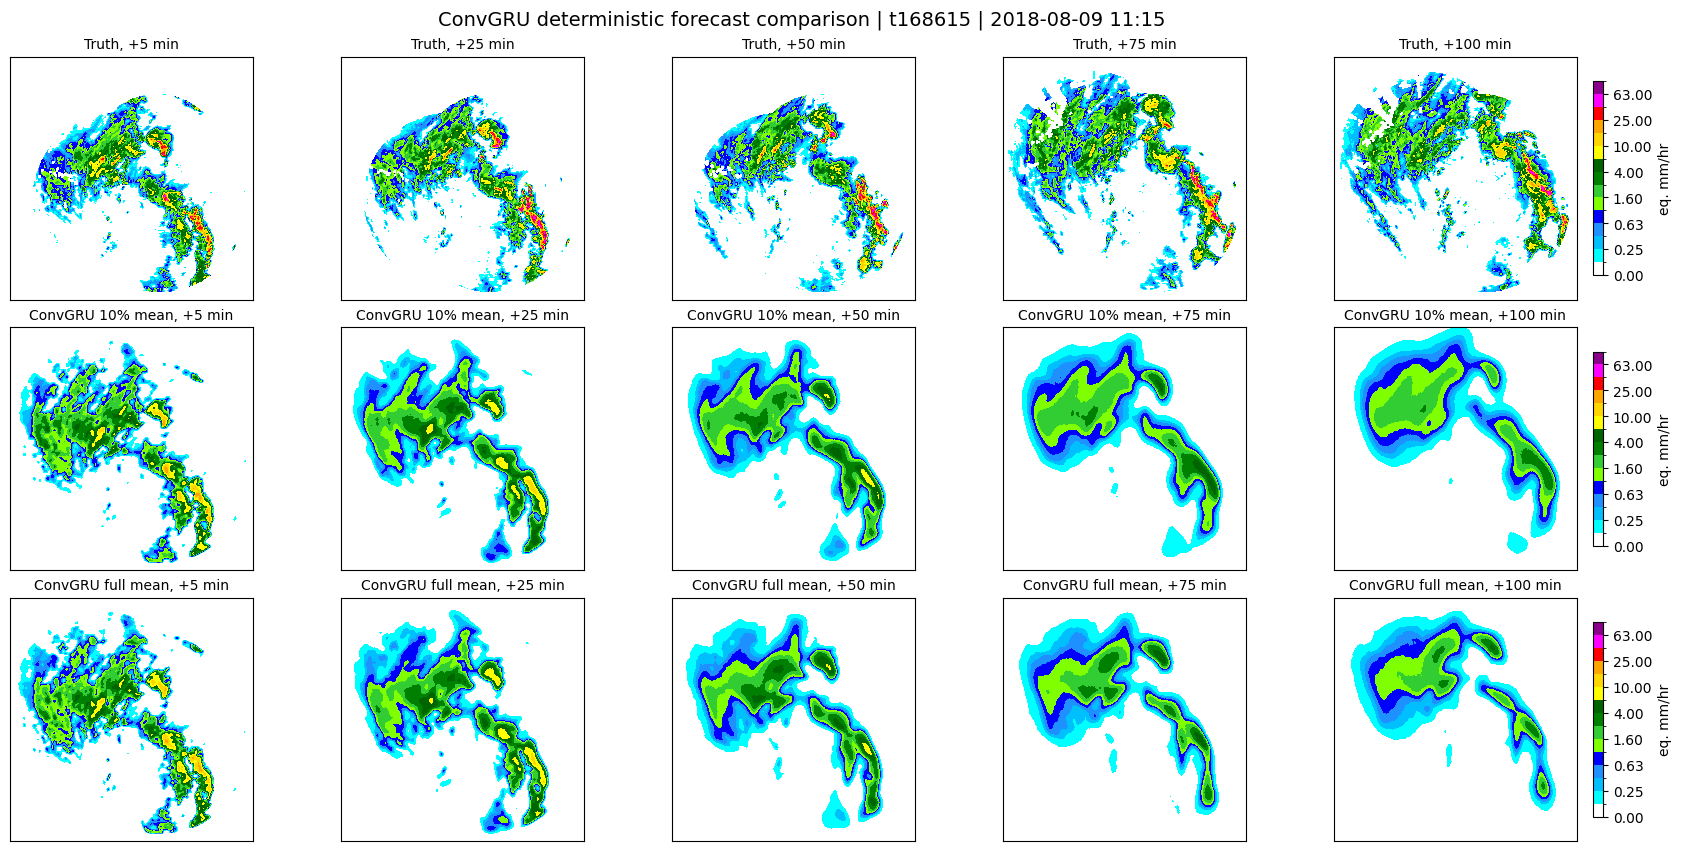

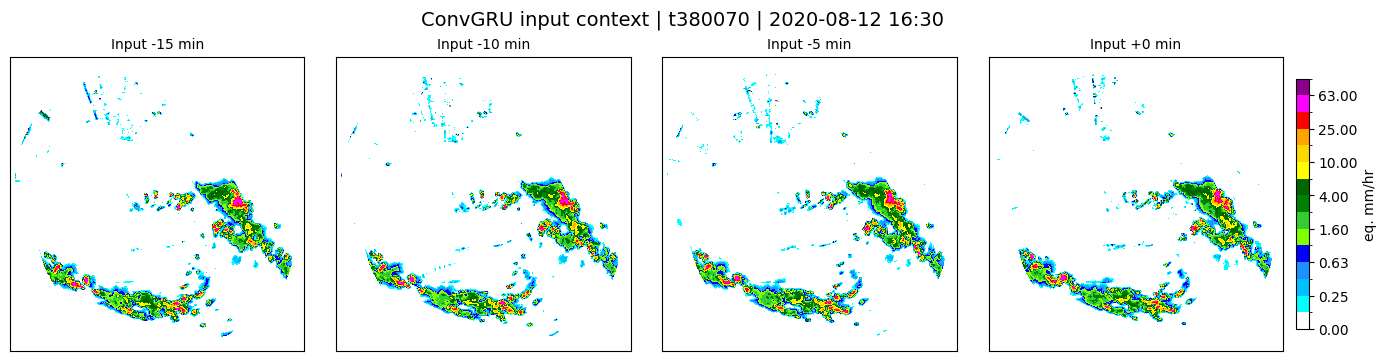

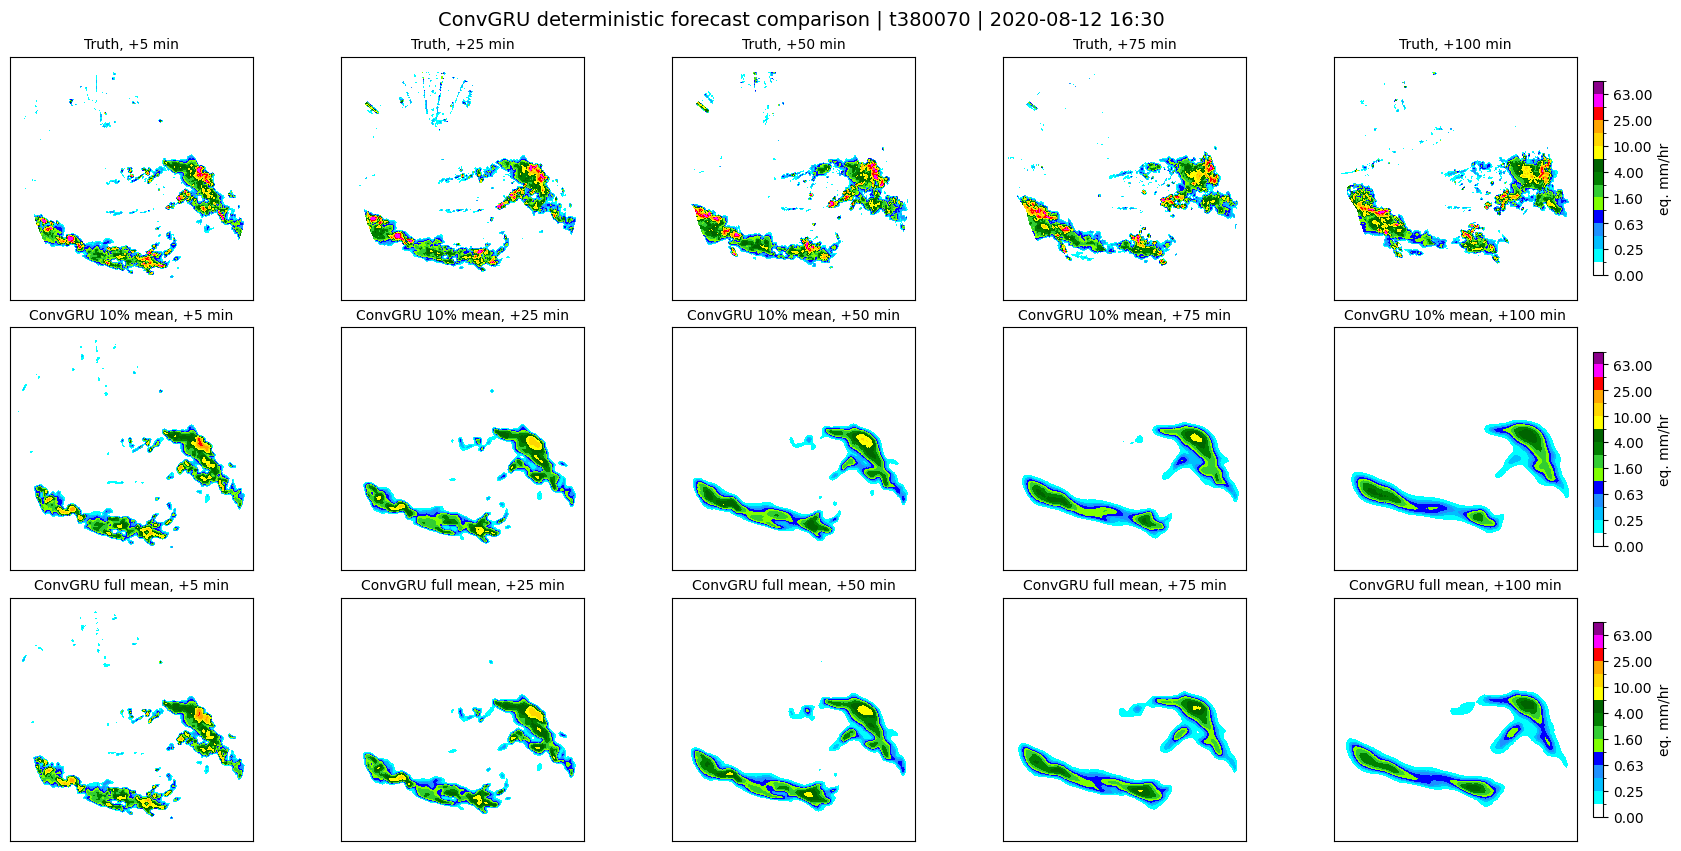

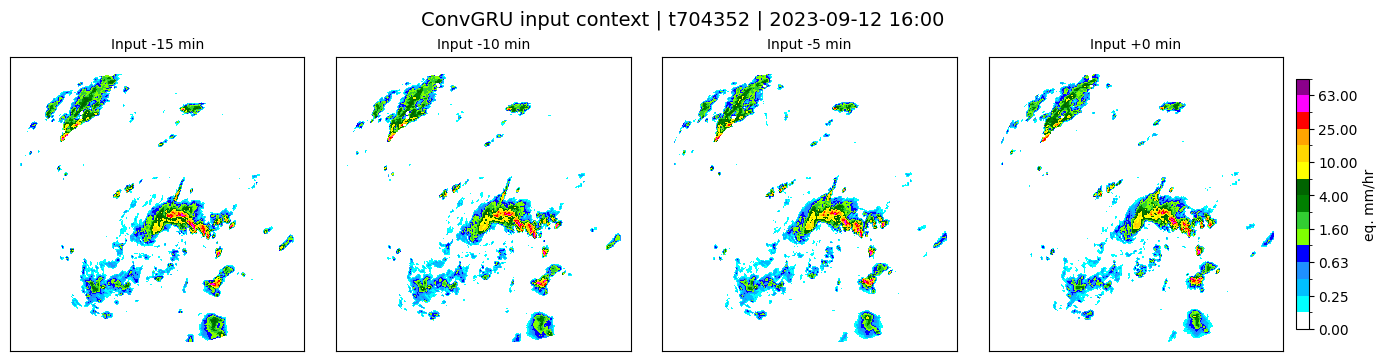

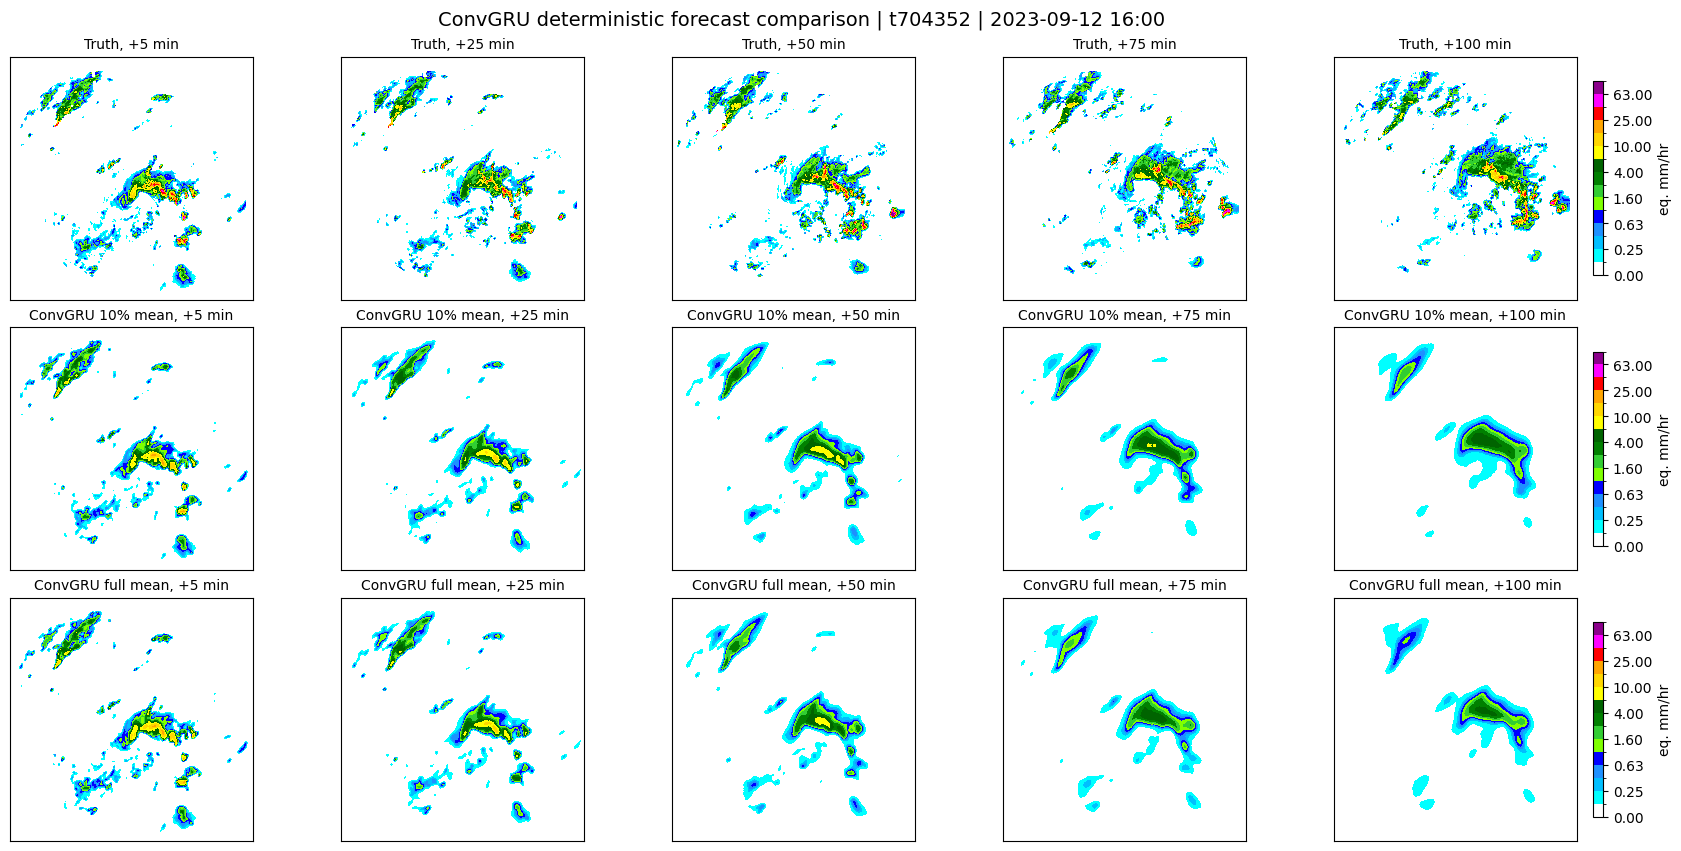

In [34]:
plot_ConvGRU_deterministic()

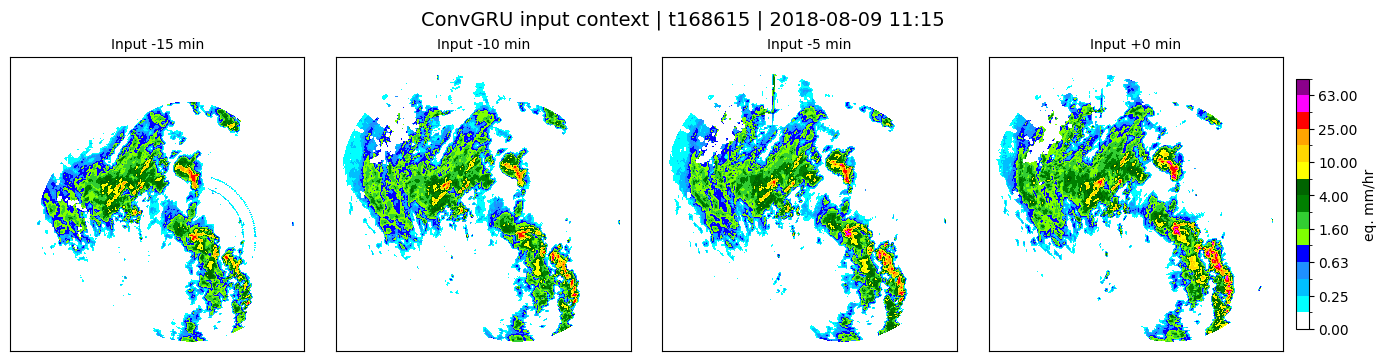

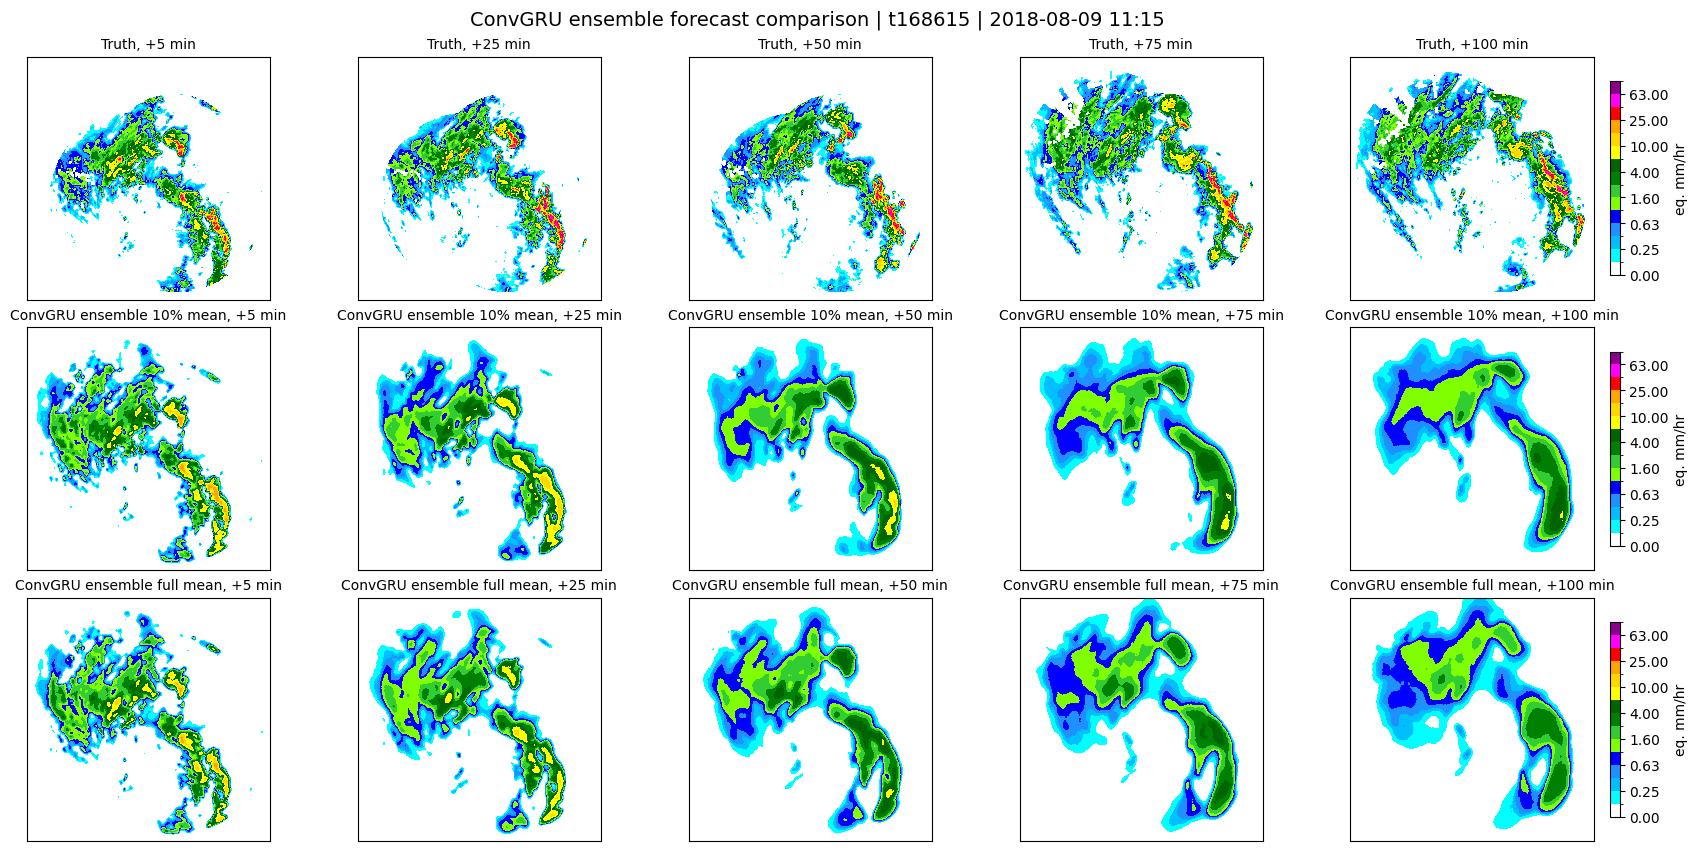

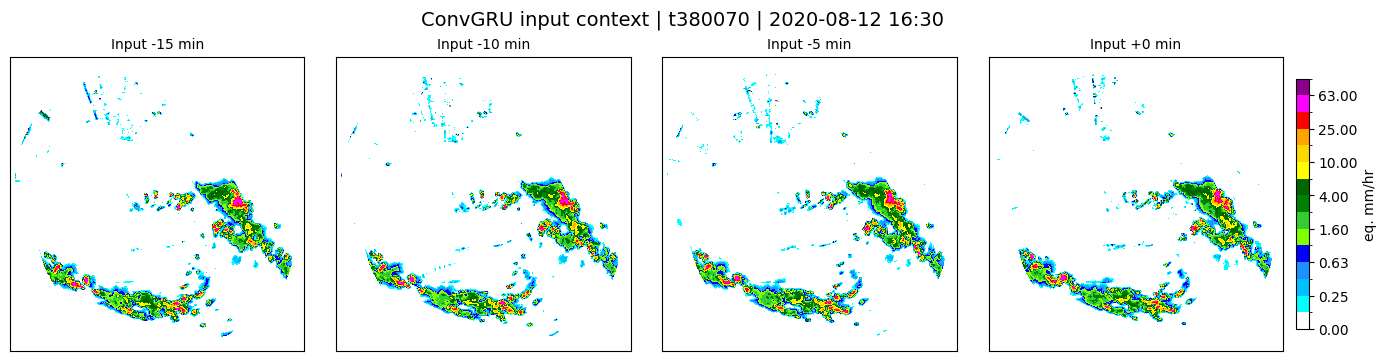

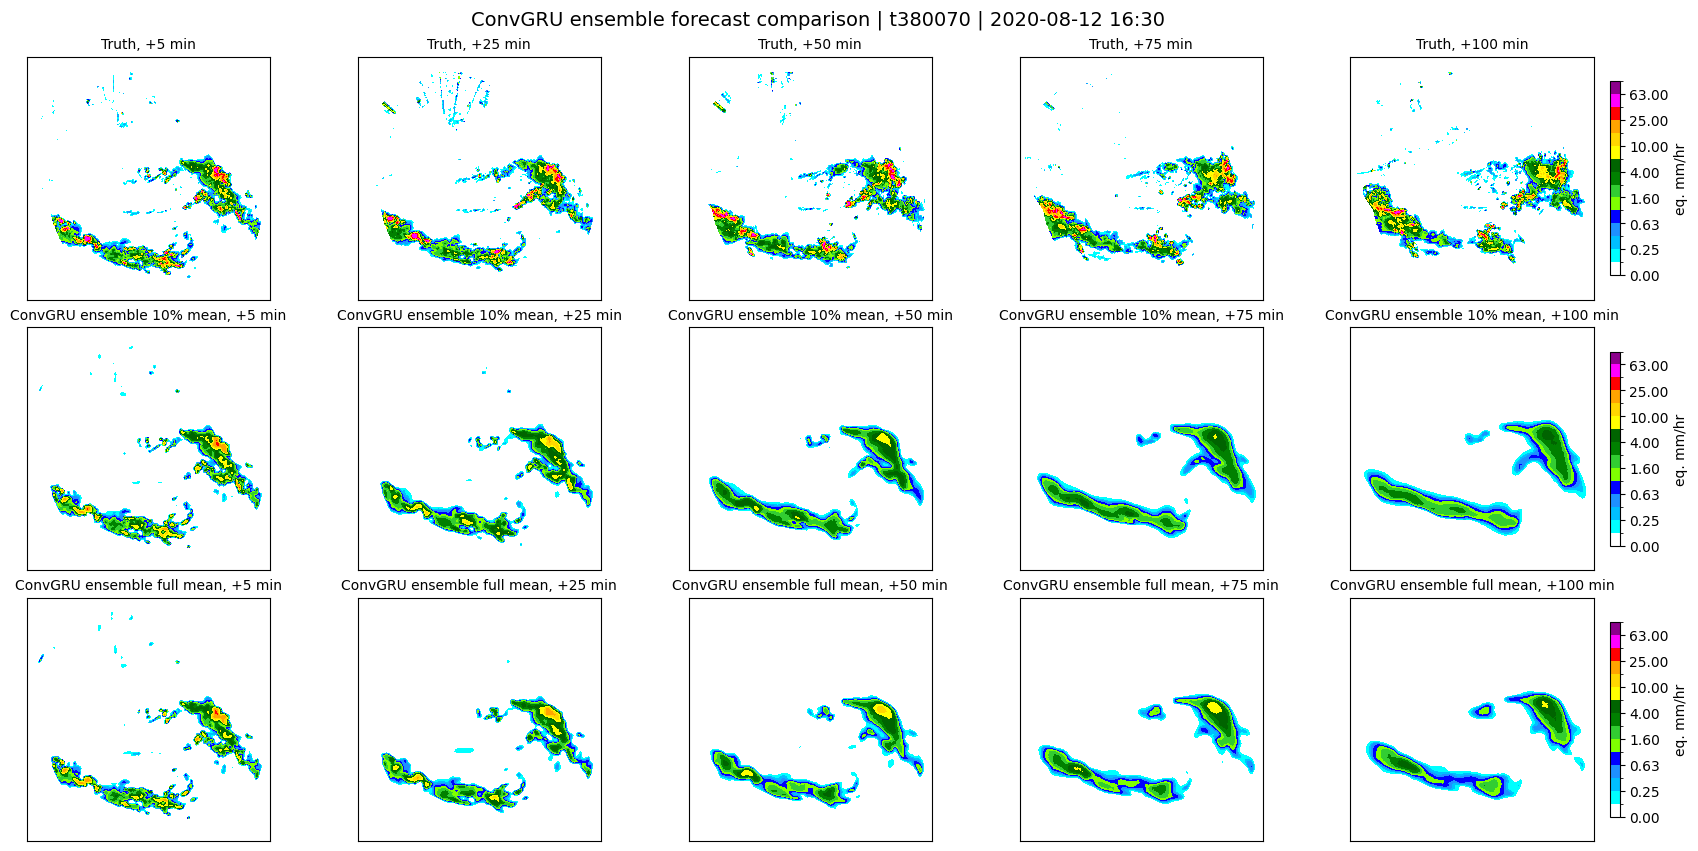

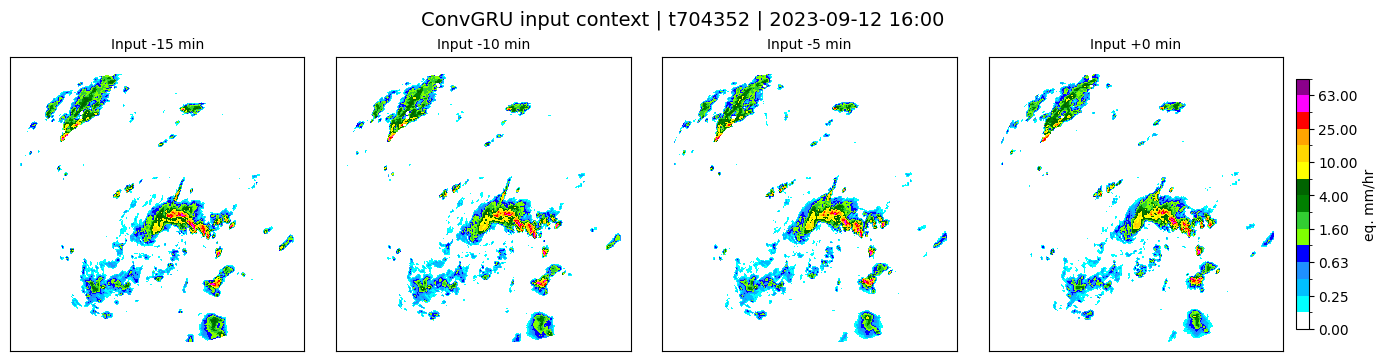

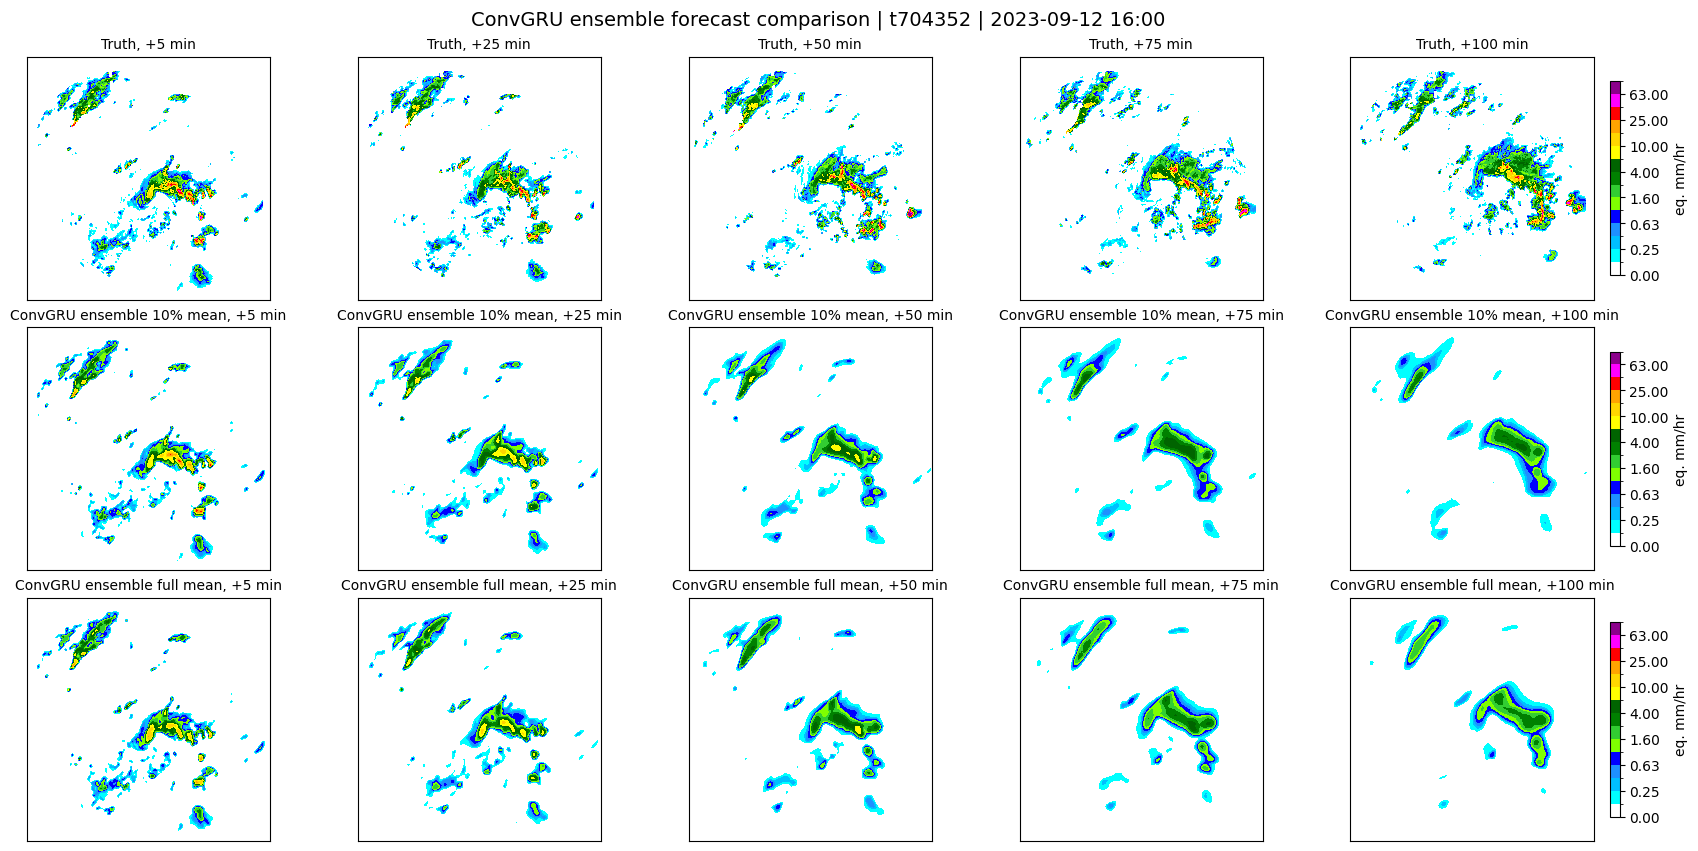

In [35]:
plot_ConvGRU_ensemble()

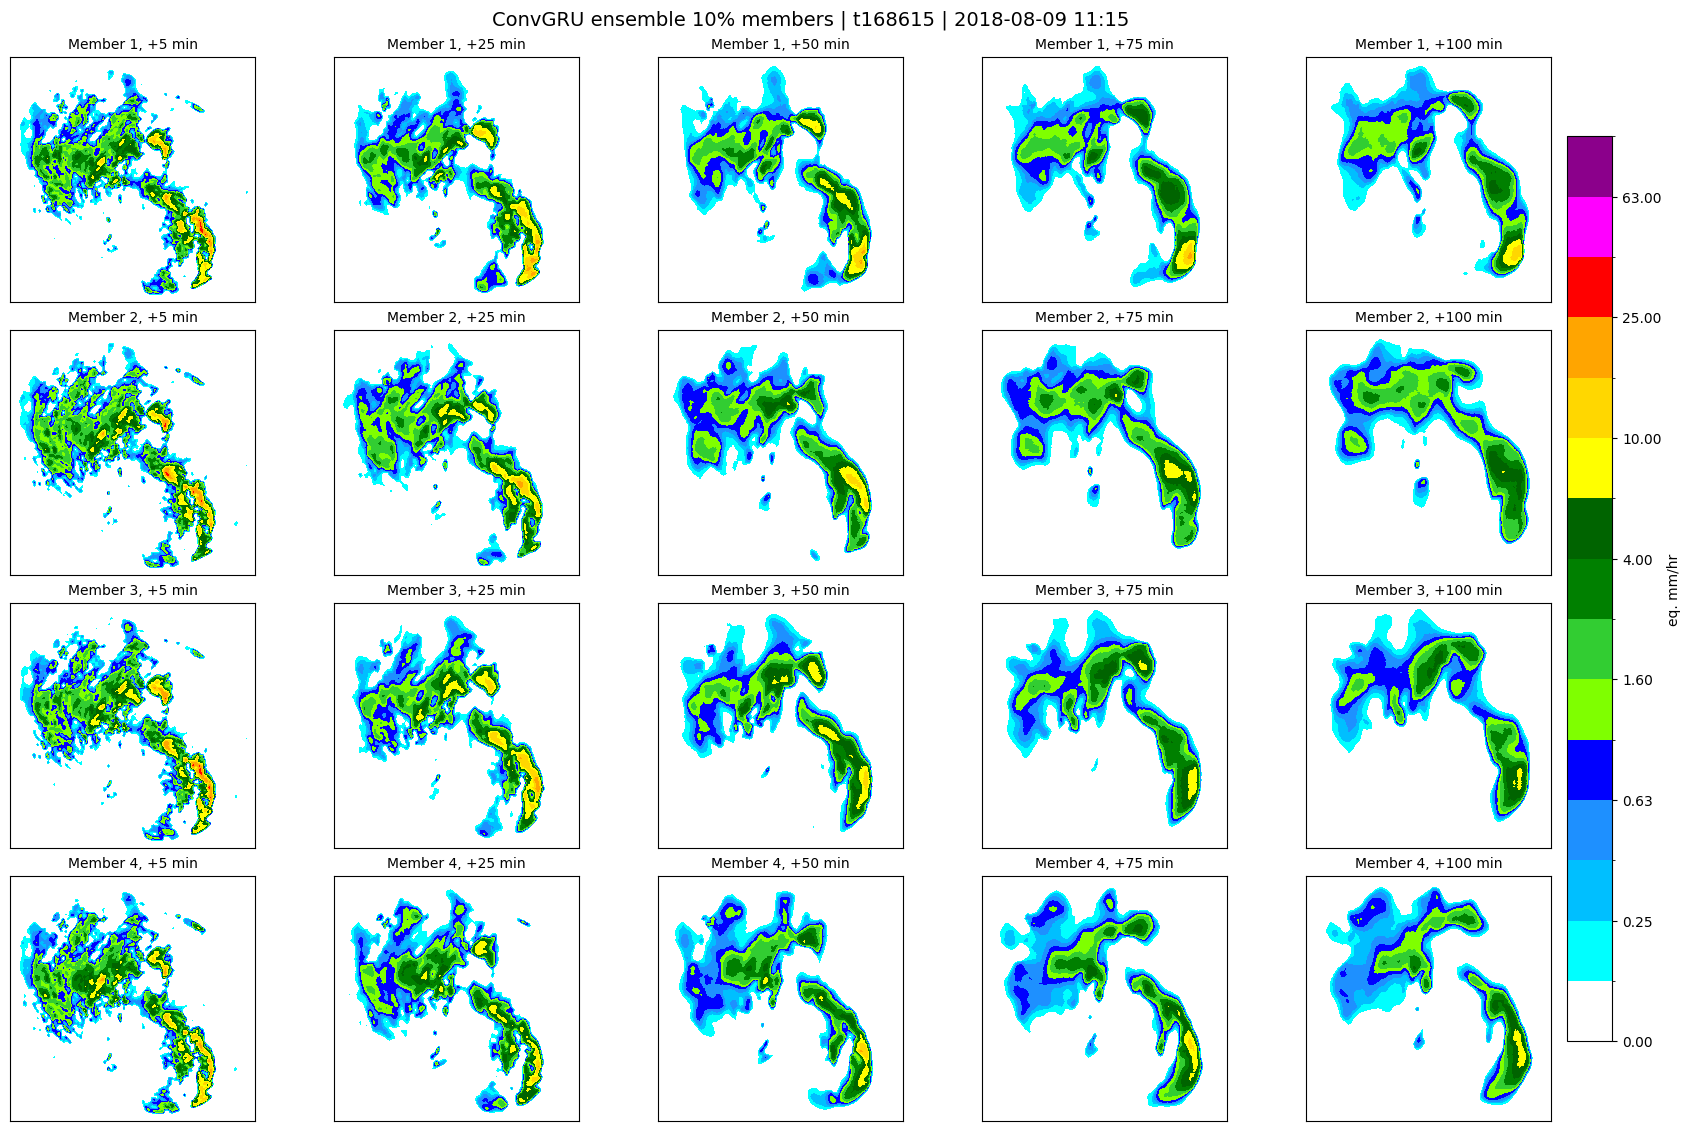

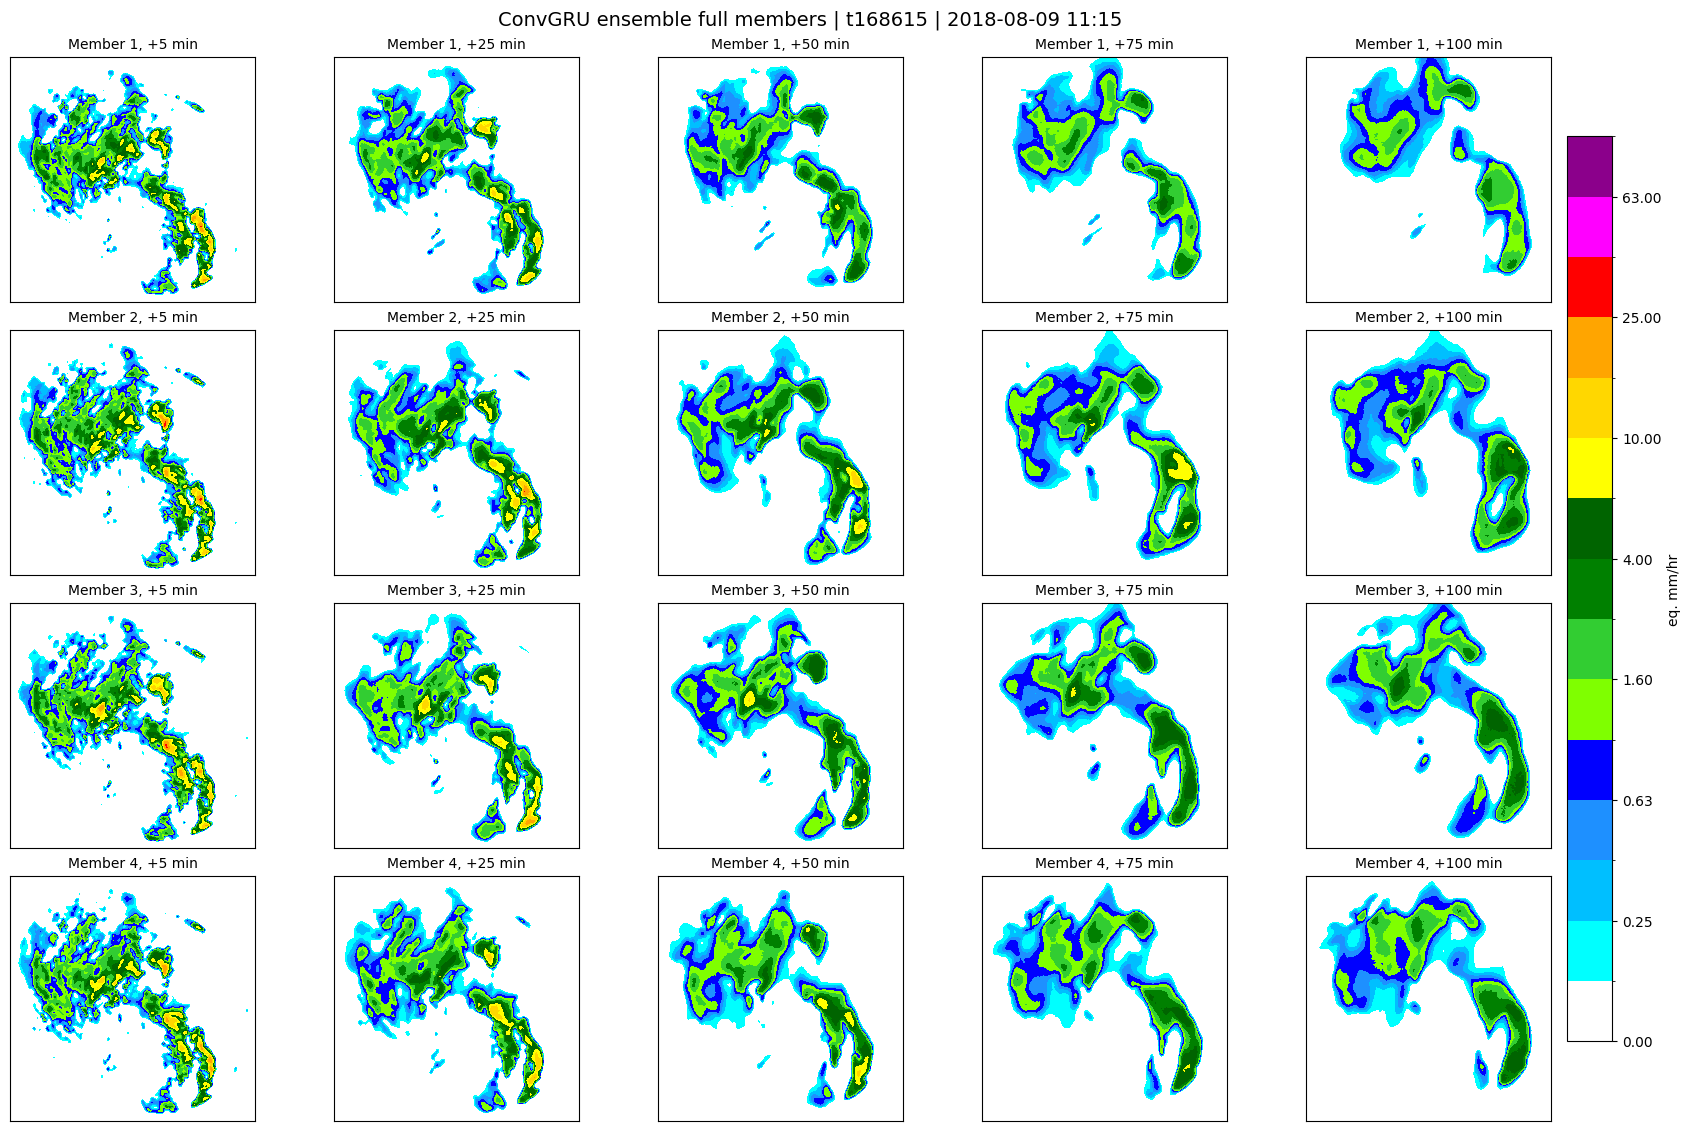

In [36]:
plot_ConvGRU_members()

### LDCast:
- 10% run: 30 epochs (~ 9h/epoch on a single H200)
- full run: 3 epochs (~ 90h/epoch on a single H200) 

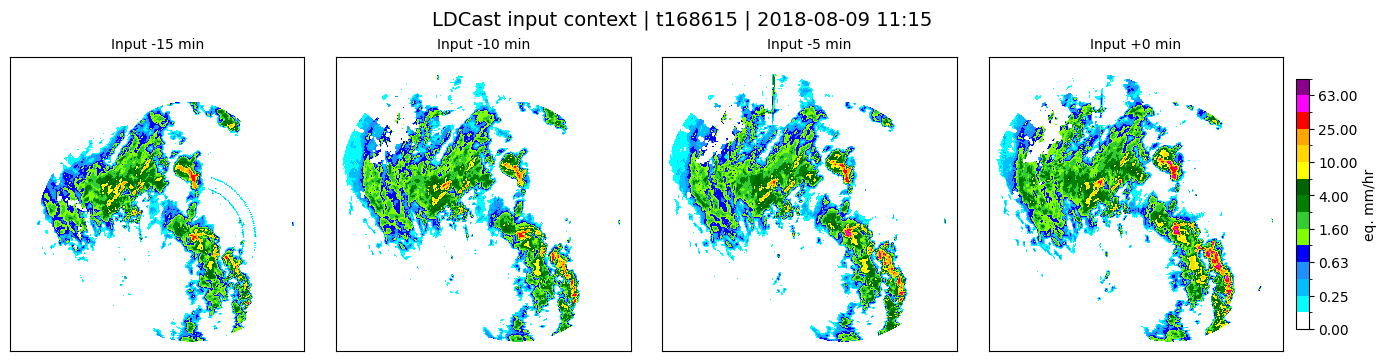

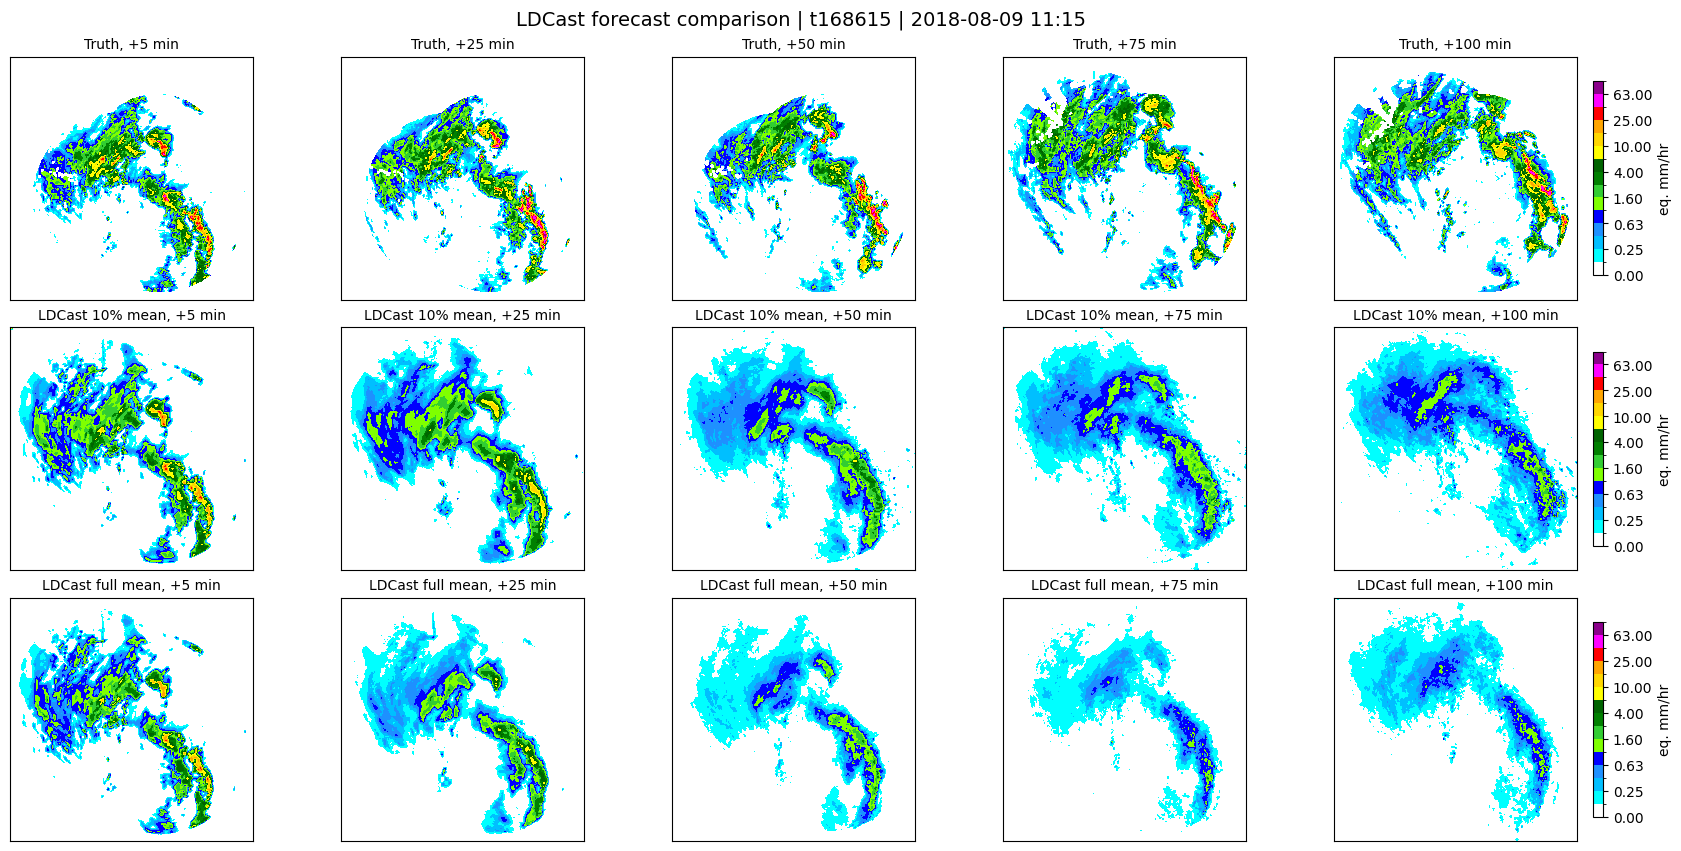

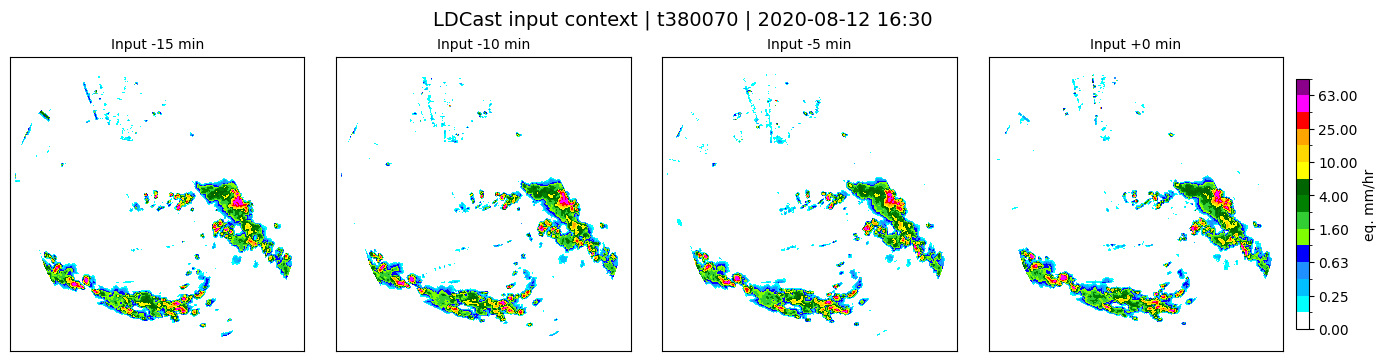

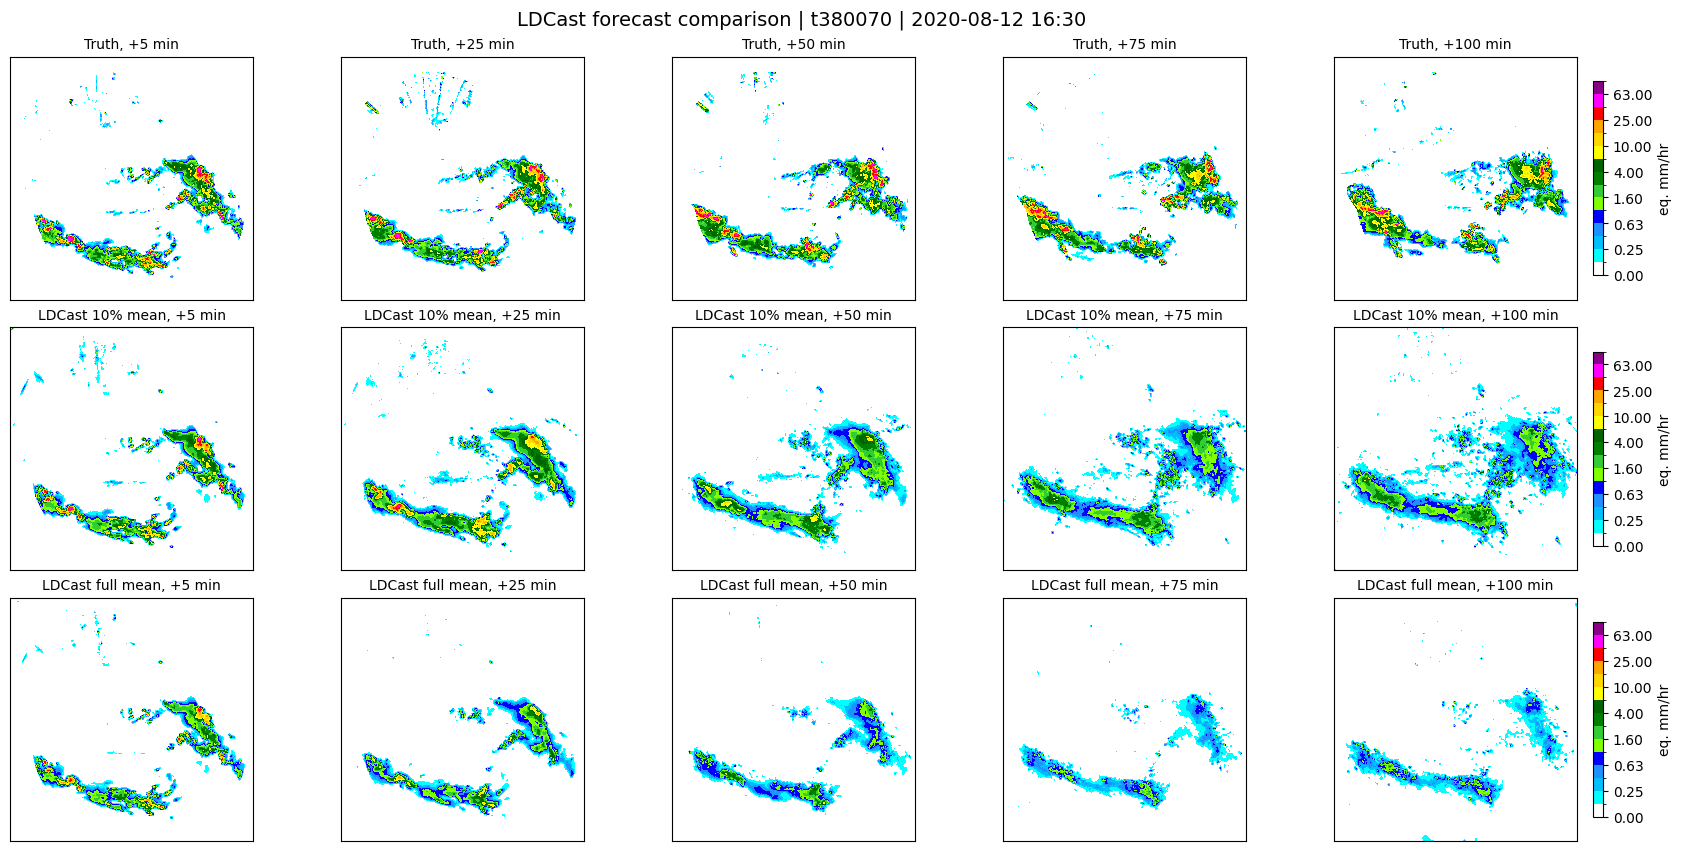

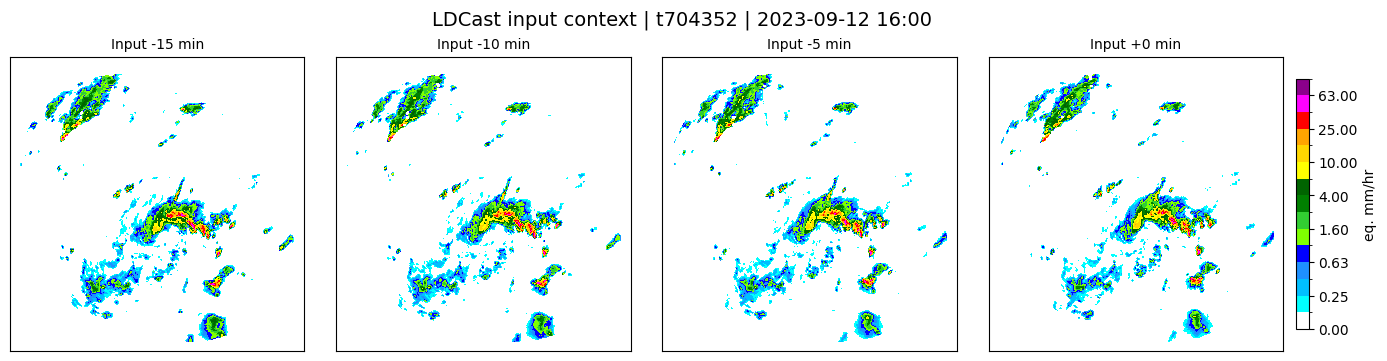

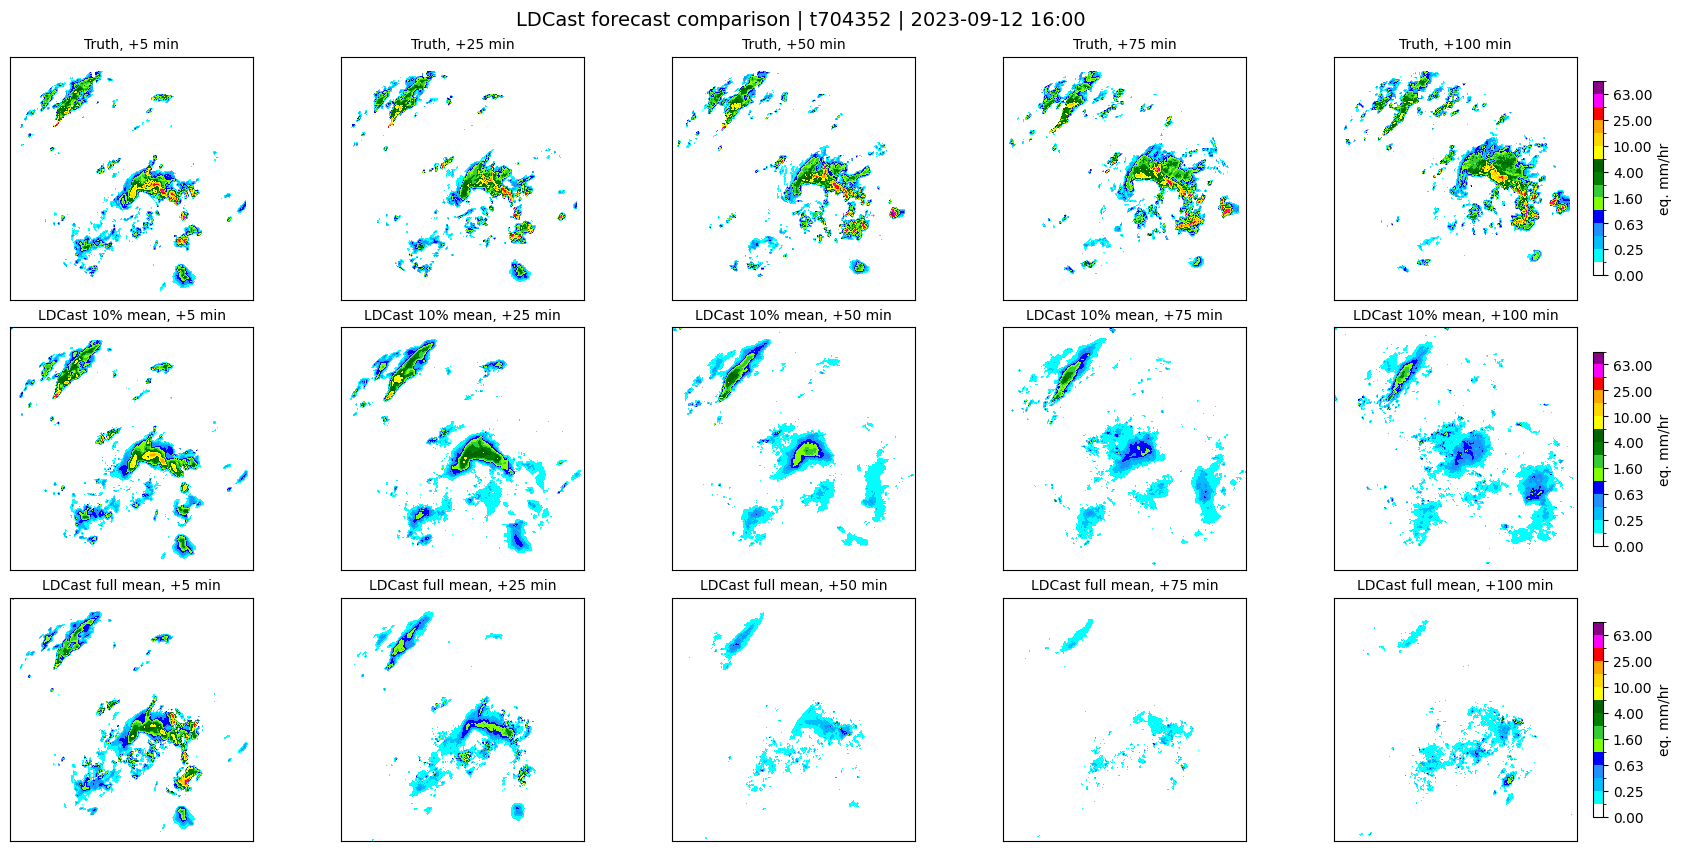

In [37]:
plot_LDCast()

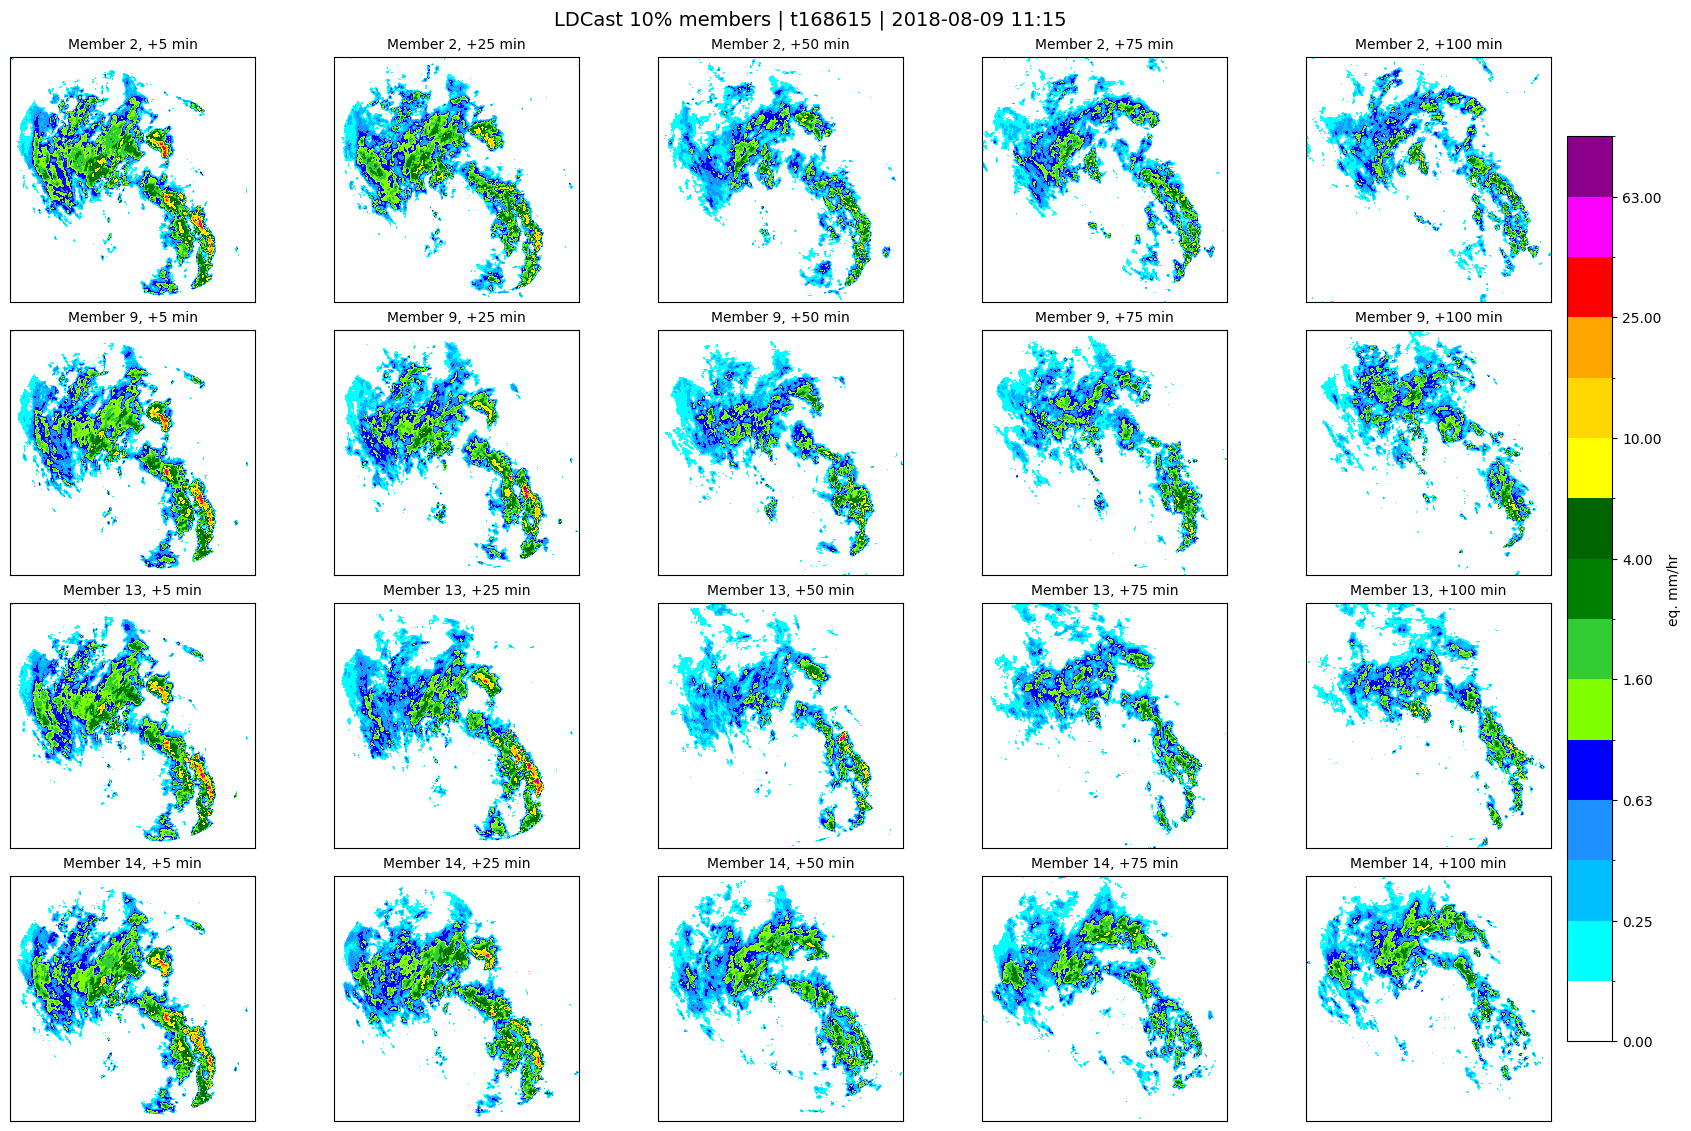

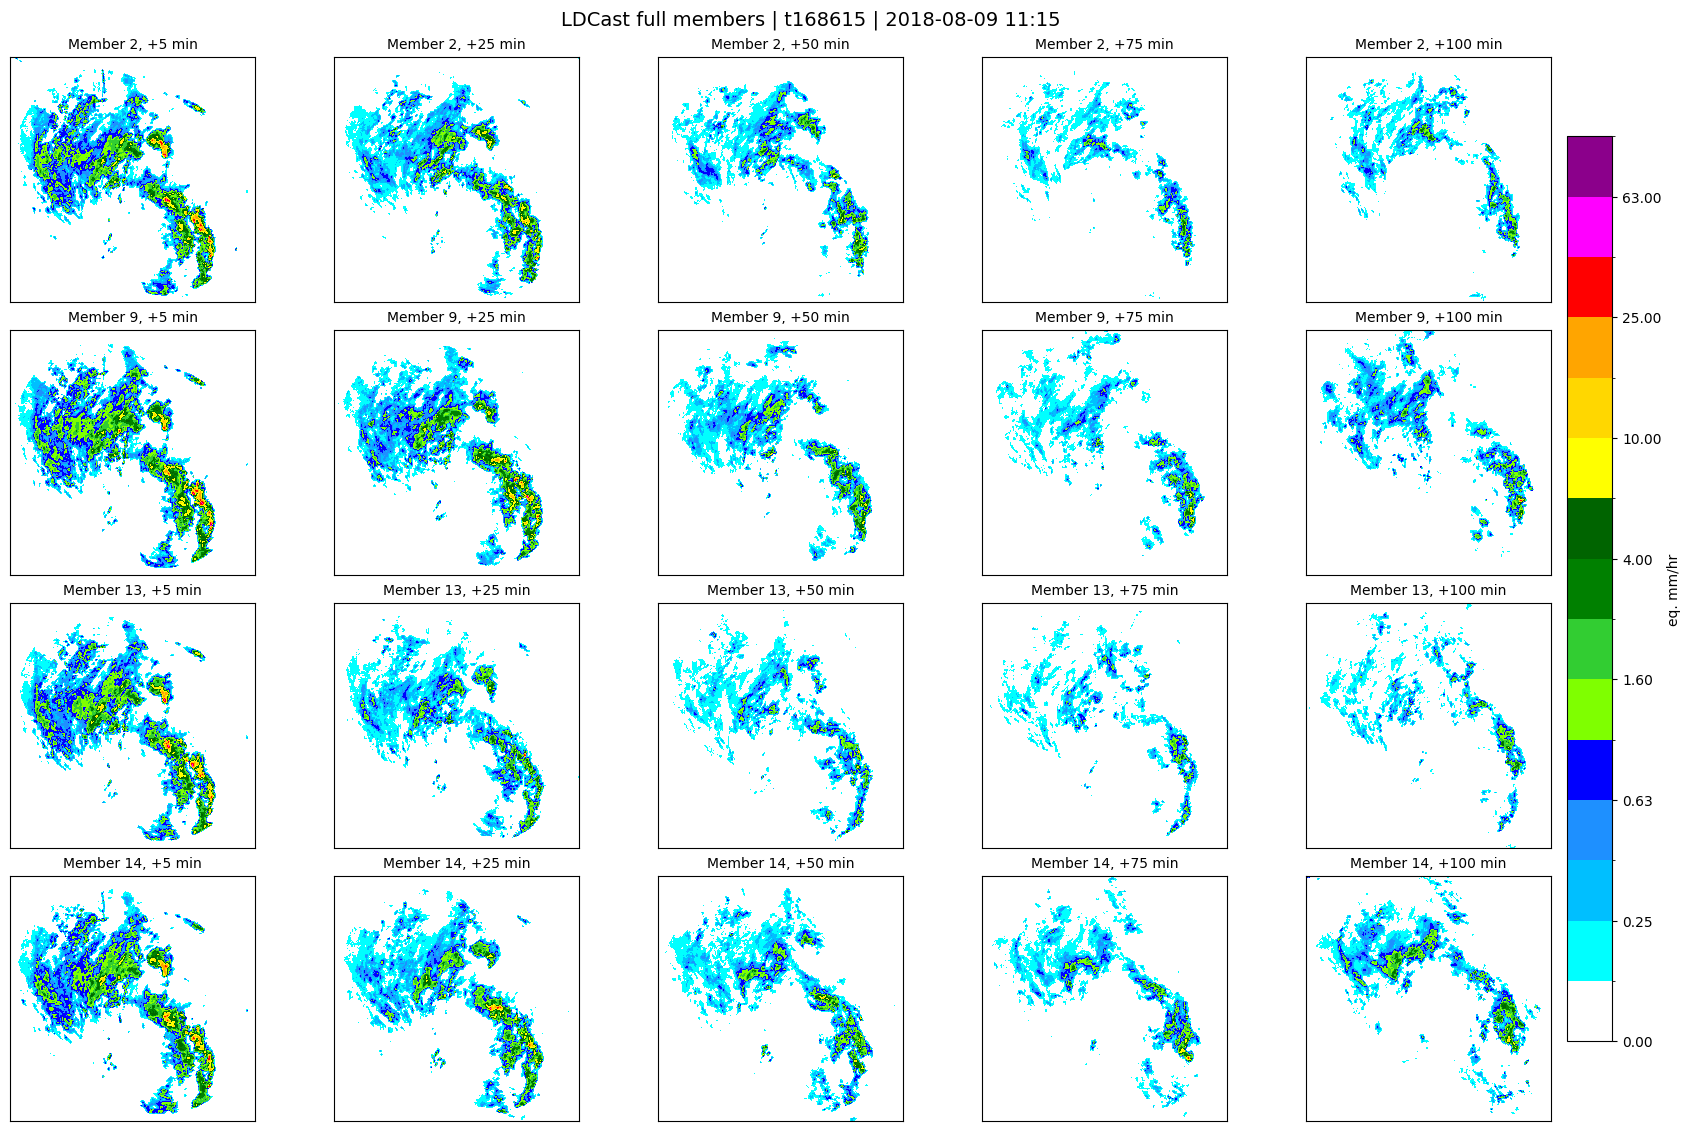

In [38]:
plot_LDCast_members()